# Two-dimensional Q-ball Bounce and Beta Scan

This notebook automates the full two-dimensional bounce computation.  Starting from the Q-ball/Q-cloud pair studied previously, we:

1. Tune $\eta_0$ at the reference value $\beta = 2\pi/\gamma - \Delta\beta$ (with $\Delta\beta=0.2$) so that the 2D solution carries the same charge as the original Q-ball.
2. Record the normalised energy $E(\tau\approx 0)/E_Q$.
3. Perform a scan in $\beta$, using the converged solution of the previous step as ansatz for the next one, and store the energy ratios for later analysis.


## Imports and Utilities

We import the modular functions developed in `Q_ball_finder/` to:

- **1D profiles**: Compute Q-ball and Q-cloud solutions $\varphi_Q(r)$ and $\varphi_{\text{cloud}}(r)$ using the one-dimensional field equations
- **Unstable modes**: Calculate the negative eigenmode $\xi_-(r)$ around the Q-cloud with eigenvalue $\gamma$ satisfying $\gamma^2 < 0$
- **Ansatz construction**: Build initial field configurations for the 2D solver using the unstable mode:
  $$\phi(r,\tau) \approx \varphi_{\text{cloud}}(r) + A_- \left[ \xi_-(r) e^{-i\gamma\tau} + \xi_-^*(r) e^{+i\gamma\tau} \right]$$
- **Newton solver**: Solve the 2D field equations using Newton-Raphson iteration on the discretized grid
- **Observables**: Compute charge $Q$ and energy $E$ from the converged 2D solution


In [ ]:
import sys 
from pathlib import Path 
 
# PROJECT_ROOT should point to the directory containing Q_ball_finder
# Structure: BubbleX/Q_ball_finder/notebooks/ -> PROJECT_ROOT = BubbleX/
PROJECT_ROOT = Path.cwd().resolve().parents[1] # BubbleX/ (che contiene Q_ball_finder) 
 
if str(PROJECT_ROOT) not in sys.path: 
 sys.path.insert(0, str(PROJECT_ROOT)) 
 
print("PROJECT_ROOT:", PROJECT_ROOT) 
 
import matplotlib as mpl 
mpl.rcParams.update({ 
 "text.usetex": True, 
 "font.family": "serif", 
 "text.latex.preamble": r"\usepackage{amsmath}\usepackage{siunitx}" 
}) 
 
mpl.rcParams.update({ 
 "font.size": 16, # dimensione base (influenza quasi tutto) 
 "axes.titlesize": 18, # titolo assi 
 "axes.labelsize": 16, # etichette assi 
 "xtick.labelsize": 14, # tick x 
 "ytick.labelsize": 14, # tick y 
 "legend.fontsize": 14, # legenda 
 "figure.titlesize": 20, # su plt.suptitle 
})

PROJECT_ROOT: /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay


In [2]:
import numpy as np 
import matplotlib as mpl 
import matplotlib.pyplot as plt 
 
from Q_ball_finder import ( 
 LogisticPotentialParams, 
 QBall2DSettings, 
 QBall2DSolver, 
 build_custom_rho_ansatz_qball2d, 
 build_negative_mode_ansatz, 
 build_qcloud_profile_for_charge, 
 build_grid, 
 compute_dimensionless_charge, 
 compute_energy, 
 compute_unstable_mode, 
 logistic_potential_chi, 
 pack_fields, 
 plot_newton_snapshots, 
 scan_eta_to_match_charge, 
 solve_fixed_beta_eta, 
 solve_qball_profile, 
 resample_ansatz 
) 
from Q_ball_finder.observables2d import compute_charge, compute_energy as compute_energy_2d
from Q_ball_finder.seed_selection import select_best_negative_mode_seed, select_best_plateau_seed, PlateauSeedResult 
 
mpl.rcParams.update({ 
 "font.size": 15, 
 "axes.titlesize": 18, 
 "axes.labelsize": 16, 
 "xtick.labelsize": 14, 
 "ytick.labelsize": 14, 
 "legend.fontsize": 14, 
 "figure.titlesize": 20, 
}) 

## One-dimensional Inputs

We start by reconstructing the Q-ball/Q-cloud pair with $m=v=1$ and $b=8$.  The resulting charge and energy feed directly into the 2D tuning procedures.


In [ ]:
params = LogisticPotentialParams(m=1.0, v=1.0, b=8.0) 
omega_qball = 0.8765 * params.m 
 
V_chi = logistic_potential_chi(params)[0] 
 
qball_profile = solve_qball_profile(params, omega_qball) 
qball_solution = qball_profile.solution 
g2Q_target = compute_dimensionless_charge(qball_solution, m=params.m, v=params.v, omega=omega_qball) 
E_Q = compute_energy(qball_solution, omega=omega_qball, potential_chi=V_chi) 
 
omega_cloud, qcloud_profile = build_qcloud_profile_for_charge( 
 params, 
 g2Q_target, 
 omega_min=0.959716 * params.m, 
 omega_max=0.999 * params.m, 
 n_points=60, 
 phi0_cap=10.0, 
 x_min=-1.0, 
 x_max=6.0, 
 prefer_side="+", 
) 

# Critical charge (for Fig. 7 normalization) evaluated at omega_min
omega_crit = 0.959716 * params.m
qball_profile_crit = solve_qball_profile(params, omega_crit)
Q_crit = compute_dimensionless_charge(
    qball_profile_crit.solution,
    m=params.m,
    v=params.v,
    omega=omega_crit,
)
 
unstable_mode = compute_unstable_mode(qcloud_profile, n_scan=30) 
 
print(f"g^2 Q target = {g2Q_target:.6f}") 
print(f"Q-ball energy E_Q = {E_Q:.6f}") 
print(f"Q_critical (at omega_min=0.959716 m) = {Q_crit:.6f}")
print(f"Q-cloud frequency ω̃/m = {omega_cloud / params.m:.6f}") 
print(f"Negative-mode γ = {unstable_mode.gamma:.6f}") 

# Selecting the best ansatz

In [39]:
# Setup parameters for seed selection
# Define grid parameters
Nr_ref = 48  # 96
Ntau_ref = 81  # 162
Lr_ref = 10.0

# Beta value for seed selection
beta_ref_natural = (2.0 * np.pi) / unstable_mode.gamma
beta_sel = beta_ref_natural*1.2

# Build grid for seed selection
grid_sel = build_grid(Nr=Nr_ref, Ntau=Ntau_ref, Lr=Lr_ref, beta=beta_sel)

settings_sel = QBall2DSettings(
    beta=beta_sel,
    ansatz_amplitude=2.5,  # kept for completeness, not used when x0 provided
    energy_reference=E_Q,
    omega_tilde=omega_cloud,
    Nr=Nr_ref,
    Ntau=Ntau_ref,
    Lr=Lr_ref,
    newton_verbose=True,
)

# Select best Q-ball → escape seed using basin test
from Q_ball_finder.seeds import select_best_qball_escape_seed

eta_sel = beta_sel * (omega_cloud - omega_qball)

best_seed = select_best_qball_escape_seed(
    params=params,
    omega_qball=omega_qball,
    qball_profile=qball_profile,  # Use Q-ball profile (NOT Q-cloud)
    mode=unstable_mode,
    grid=grid_sel,
    settings=settings_sel,
    eta=eta_sel,
    target_charge=g2Q_target,
    a_plateaus=(0.2, 0.3, 0.4),
    tau_transitions=(-12.0, -15.0, -18.0, -21.0),
    tau_widths=(2.0, 3.0, 4.0),
    kick_amps=(1.0, 2.0),
    kick_thetas=(0.0,),
    kick_tau_widths=(4.0, 6.0),
    cosh_scales=(None,),
    flip_signs=(False,),
    rho0_target=0.5,
    tau_variation_min=0.2,
    w_rho0=10.0,
    w_cloud=100.0,
    w_Q=2.0,
    basin_newton_iters=5,
    basin_damping=0.5,
    verbose=True,
)

x0_best = best_seed.best_x0
print("\nBEST Q-BALL ESCAPE SEED:")
print(f"  Parameters: {best_seed.best_params}")
print(f"  Score = {best_seed.best_score:.6e}, ||F|| = {best_seed.best_residual_norm:.6e}")
print(f"  rho0 = {best_seed.best_rho0:.6f} (target 0.5), tau_variation = {best_seed.best_tau_variation:.6f}")
print(f"  Q_ratio = {best_seed.best_charge_ratio:.6f}")
cloud_like_status = "CLOUD-LIKE" if best_seed.best_tau_variation < 0.2 else "ESCAPE-LIKE"
print(f"  Classification: {cloud_like_status}")

# Solve with the best Q-ball → escape seed

solution_sel, charge_sel, x0_sel = solve_fixed_beta_eta(
    params,
    omega_qball,
    qcloud_profile,
    unstable_mode,
    settings=settings_sel,
    eta=eta_sel,
    x0_initial=x0_best,
    verbose=True,
)

print(f"\nSolution with best Q-ball → escape seed:")
print(f"  Charge = {charge_sel:.6f} (ratio {charge_sel / g2Q_target:.6f})")
if solution_sel.energy is not None:
    print(f"  Energy (τ≈0) = {solution_sel.energy:.6f}")
    if solution_sel.energy_ratio is not None:
        print(f"  Energy ratio = {solution_sel.energy_ratio:.6f}")

Evaluating 144 Q-ball escape seed candidates with basin test...
  Basin test: 5 iterations, damping=0.5
  Scoring: rho0_target=0.500, tau_variation_min=0.200
  Weights: w_rho0=10.0, w_cloud=100.0, w_Q=2.0
Step 1: Quick residual evaluation for 144 candidates...
  Progress: 20/144
  Progress: 40/144
  Progress: 60/144
  Progress: 80/144
  Progress: 100/144
  Progress: 120/144
  Progress: 140/144

Step 2: Basin test for top 5 candidates (by residual norm)...
  Top 5 residual norms: ['2.842507e+02', '2.845685e+02', '2.853021e+02', '2.856888e+02', '2.861278e+02']
  Top 1: ||F||=2.538269e+01, rho0=0.4888, tau_var=1.9672, score=3.777976e+00
  Top 2: ||F||=2.916964e+01, rho0=0.5035, tau_var=1.9116, score=3.742353e+00
  Top 3: ||F||=3.023708e+01, rho0=0.5124, tau_var=1.8915, score=3.942923e+00
  Top 4: ||F||=2.717047e+01, rho0=0.4954, tau_var=1.9443, score=3.669205e+00
  Top 5: ||F||=6.493764e+01, rho0=0.4875, tau_var=2.0330, score=4.862329e+00

Best Q-ball escape seed found:
  Score = 3.669205

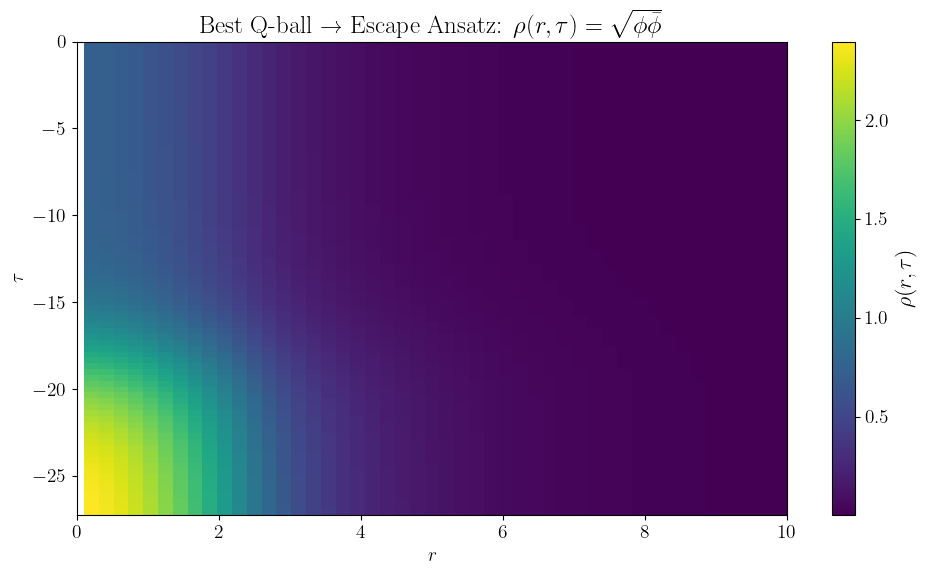

In [40]:
# Plot the best Q-ball escape ansatz: density rho (sanity check)
from Q_ball_finder.ansatz import build_qball_escape_ansatz

# Reconstruct the best ansatz for visualization
ansatz_best = build_qball_escape_ansatz(
    qball_profile=qball_profile,
    mode=unstable_mode,
    grid=grid_sel,
    omega_reference=omega_qball,
    a_plateau=best_seed.best_params["a_plateau"],
    tau_transition=best_seed.best_params["tau_transition"],
    tau_width=best_seed.best_params["tau_width"],
    kick_amp=best_seed.best_params["kick_amp"],
    kick_theta=best_seed.best_params["kick_theta"],
    kick_tau_width=best_seed.best_params["kick_tau_width"],
    cosh_scale=best_seed.best_params["cosh_scale"],
    flip_sign=best_seed.best_params["flip_sign"],
    omega_tilde=settings_sel.omega_tilde,
    decrease_towards_zero=False,
)

# Compute density rho = sqrt(phi * phibar)
rho_ansatz = np.sqrt(np.maximum((ansatz_best.phi * ansatz_best.phibar).real, 0.0))

# Create meshgrid for plotting
R_ansatz, T_ansatz = np.meshgrid(grid_sel.r, grid_sel.tau, indexing="xy")

# Plot 2D density
fig, ax = plt.subplots(figsize=(10, 6))
cf = ax.pcolormesh(R_ansatz, T_ansatz, rho_ansatz.T, shading="auto", cmap="viridis")
ax.set_xlabel(r"$r$", fontsize=14)
ax.set_ylabel(r"$\tau$", fontsize=14)
ax.set_title(r"Best Q-ball → Escape Ansatz: $\rho(r, \tau) = \sqrt{\phi \bar{\phi}}$")
ax.set_xlim(0, min(12, grid_sel.r.max()))
fig.colorbar(cf, ax=ax, label=r"$\rho(r, \tau)$")
plt.tight_layout()
plt.show()

In [32]:
beta_escape = beta_sel

Nr_fine = Nr_ref * 2
Ntau_fine = Ntau_ref * 2
Lr_ref = Lr_ref * 2

grid_fine = build_grid(Nr=Nr_fine, Ntau=Ntau_fine, Lr=Lr_ref, beta=beta_escape)

from Q_ball_finder.ansatz import AnsatzResult
from Q_ball_finder.notebook_utils import resample_ansatz
from Q_ball_finder.grid import unpack_fields, phi_from_y, phi_from_ybar

y_best, ybar_best = unpack_fields(x0_best, grid_sel.Nr, grid_sel.Ntau)
phi_best = phi_from_y(y_best, grid_sel, omega_qball)
phibar_best = phi_from_ybar(ybar_best, grid_sel, omega_qball)

ansatz_best = AnsatzResult(
    phi=phi_best,
    phibar=phibar_best,
    y=y_best,
    ybar=ybar_best,
)

ansatz_fine = resample_ansatz(
    ansatz_best,
    grid_sel,
    grid_fine,
    omega=omega_qball,
)

x0_fine = pack_fields(ansatz_fine.y, ansatz_fine.ybar)

settings_fine = QBall2DSettings(
    beta=beta_escape,
    ansatz_amplitude=2.5,
    energy_reference=E_Q,
    omega_tilde=omega_cloud,
    Nr=Nr_fine,
    Ntau=Ntau_fine,
    Lr=Lr_ref,
    newton_verbose=True,
)

eta_escape = beta_escape * (omega_cloud - omega_qball)

solution_fine, charge_fine, x0_fine_final = solve_fixed_beta_eta(
    params,
    omega_qball,
    qcloud_profile,
    unstable_mode,
    settings=settings_fine,
    eta=eta_escape,
    x0_initial=x0_fine,
    verbose=True,
)

print(f"\n--- Solution with fine grid (Nr={Nr_fine}, Ntau={Ntau_fine}) ---")
print(f"Fixed β = {beta_escape:.6f}, η = {eta_escape:.6f}")
print(f"Charge = {charge_fine:.6f} (ratio {charge_fine / g2Q_target:.6f})")
if solution_fine.energy is not None:
    print(f"Energy (τ≈0) = {solution_fine.energy:.6f}")
if solution_fine.energy_ratio is not None:
    print(f"Energy ratio = {solution_fine.energy_ratio:.6f}")

[Newton-explicit] iter=01, ||F||=9.474e+02, charge=9.014072e+00
[Newton-explicit] iter=02, ||F||=1.107e+03, charge=2.816859e+02
[Newton-explicit] iter=03, ||F||=1.302e+02, charge=4.860086e+02
[Newton-explicit] iter=04, ||F||=1.563e+03, charge=5.655065e+02
[Newton-explicit] iter=05, ||F||=1.244e+03, charge=8.268013e+02
[Newton-explicit] iter=06, ||F||=4.986e+03, charge=6.464749e+01
[Newton-explicit] iter=07, ||F||=6.571e+03, charge=1.244768e+02
[Newton-explicit] iter=08, ||F||=3.748e+04, charge=3.296336e+04
[Newton-explicit] iter=09, ||F||=4.774e+04, charge=2.124998e+05
[Newton-explicit] iter=10, ||F||=1.243e+05, charge=4.483746e+04
[Newton-explicit] iter=11, ||F||=1.858e+05, charge=7.029034e+06
[Newton-explicit] iter=12, ||F||=6.576e+06, charge=3.465638e+08
[Newton-explicit] iter=13, ||F||=2.234e+07, charge=6.884725e+08
[Newton-explicit] iter=14, ||F||=6.026e+08, charge=1.077814e+11


KeyboardInterrupt: 

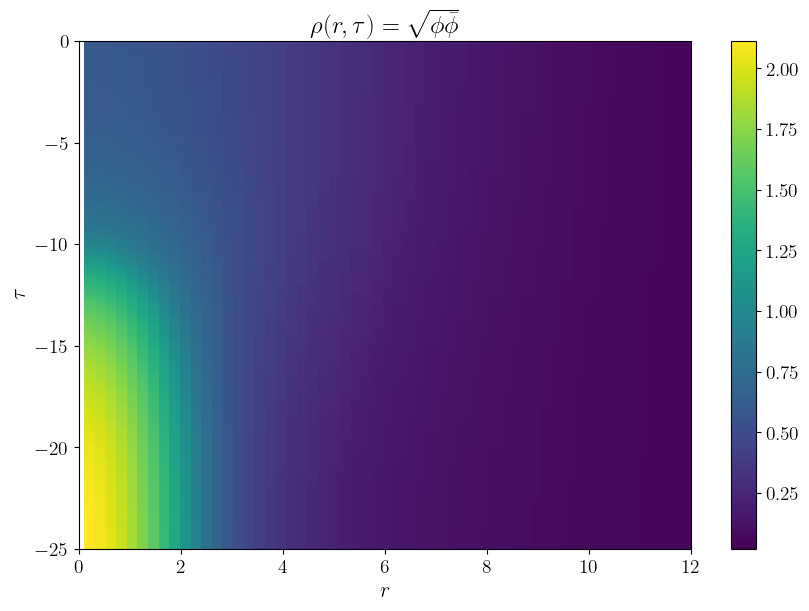

In [18]:
# Plot the solution
grid_plot = solution_fine.grid
R, T = np.meshgrid(grid_plot.r, grid_plot.tau, indexing="xy")

# Compute density rho = sqrt(phi * phibar)
rho_solution = np.sqrt(np.maximum((solution_fine.phi * solution_fine.phibar).real, 0.0))

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

# Plot density rho
cf = ax.pcolormesh(R, T, rho_solution.T, shading="auto")
ax.set_title(r"$\rho(r,\tau) = \sqrt{\phi\bar{\phi}}$")
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$\tau$")
ax.set_xlim(0, min(12, grid_plot.r.max()))
fig.colorbar(cf, ax=ax)

plt.show()

In [19]:
# Scan eta to match target charge using the solution from the fine grid
eta_start_scan = eta_escape

# Use x0_fine_final from the fine grid solution
x0_from_escape = x0_fine_final

result_scan = scan_eta_to_match_charge(
    params,
    omega_qball,
    qcloud_profile,
    unstable_mode,
    settings=settings_fine,
    eta_start=eta_start_scan,
    target_charge=g2Q_target,
    d_eta=0.1,
    max_scan_steps=30,
    tol=1e-4,
    verbose=True,
    x0_initial=x0_from_escape,  # Use the Lr=20 solution as initial ansatz
)

print(f"\nEta scan completed:")
print(f"  Converged η* = {result_scan.eta:.6f}")
print(f"  Charge = {result_scan.charge:.6f} (ratio {result_scan.charge / g2Q_target:.6f})")
if result_scan.solution.energy is not None:
    print(f"  Energy (τ≈0) = {result_scan.solution.energy:.6f}")
    if result_scan.solution.energy_ratio is not None:
        print(f"  Energy ratio = {result_scan.solution.energy_ratio:.6f}")

# Store the final solution after eta scan
solution_scan = result_scan.solution

[Newton-explicit] iter=01, ||F||=6.042e-09, charge=4.695087e+02
[eta-scan] eta = 5.753935, charge = 4.695087e+02, target = 3.529285e+02, ratio = 1.330323
[eta-scan] try eta = 5.653935, charge = 4.334373e+02, ratio = 1.228117
[eta-scan] try eta = 5.553935, charge = 4.079566e+02, ratio = 1.155919
[eta-scan] try eta = 5.453935, charge = 3.887824e+02, ratio = 1.101590
[eta-scan] try eta = 5.353935, charge = 3.735196e+02, ratio = 1.058344
[eta-scan] try eta = 5.253935, charge = 3.606662e+02, ratio = 1.021924
[eta-scan] try eta = 5.153935, charge = 3.490742e+02, ratio = 0.989079
[eta-root] eta = 5.253935 (cached), charge = 3.606662e+02, ratio = 1.021924
[eta-root] eta = 5.153935 (cached), charge = 3.490742e+02, ratio = 0.989079
[eta-root] eta = 5.187185, charge = 3.528596e+02, ratio = 0.999805
[eta-root] eta = 5.187785, charge = 3.529282e+02, ratio = 0.999999
[eta-root] eta = 5.188094, charge = 3.529636e+02, ratio = 1.000100
[eta-scan] eta* = 5.187785, charge = 3.529282e+02, ratio = 0.999999

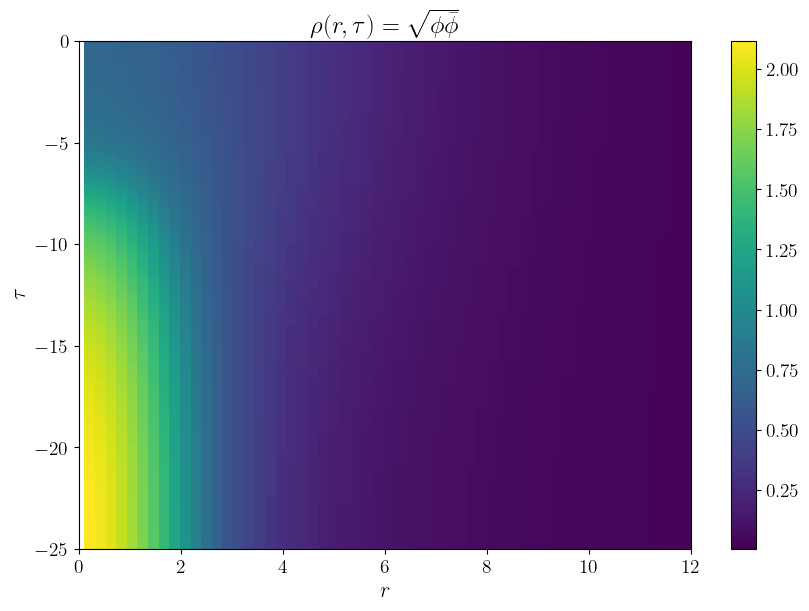

In [21]:
# Plot the solution
grid_plot = result_scan.solution.grid
R, T = np.meshgrid(grid_plot.r, grid_plot.tau, indexing="xy")

# Compute density rho = sqrt(phi * phibar)
rho_solution = np.sqrt(np.maximum((result_scan.solution.phi * result_scan.solution.phibar).real, 0.0))

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

# Plot density rho
cf = ax.pcolormesh(R, T, rho_solution.T, shading="auto")
ax.set_title(r"$\rho(r,\tau) = \sqrt{\phi\bar{\phi}}$")
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$\tau$")
ax.set_xlim(0, min(12, grid_plot.r.max()))
fig.colorbar(cf, ax=ax)

plt.show()

# Q-ball solution for $Q=352.928470$

In [4]:
# Import helper functions for beta scan continuation and charge diagnostics 
from Q_ball_finder.beta_scan_continuation import ( 
 compute_ntau_for_beta, 
 enforce_plateau_after_resample, 
 prepare_warm_start_for_beta_continuation, 
) 
from Q_ball_finder.observables2d import compute_charge 
from Q_ball_finder.ansatz import AnsatzResult 
from Q_ball_finder.grid import build_grid, pack_fields 
from Q_ball_finder.notebook_utils import resample_ansatz, warm_start_from_solution 

In [5]:
delta_beta = 0.2 
beta_ref_natural = (2.0 * np.pi) / unstable_mode.gamma 
beta_ref = 55.0 - 0.2# manual override used in the reference runs or 
 
Nr_ref = 48 * 2 
Ntau_ref = 81 * 2 
Lr_ref = 15.0 
 
# --- Negative-mode ansatz built directly in (y, ybar) and packed for the solver --- 
grid_ref = build_grid(Nr=Nr_ref, Ntau=Ntau_ref, Lr=Lr_ref, beta=beta_ref) 
neg_mode_ansatz = build_negative_mode_ansatz( 
 profile=qcloud_profile, 
 mode=unstable_mode, 
 grid=grid_ref, 
 omega_reference=omega_cloud, 
 amplitude=4.001,#4,#1 
 cosh_scale=3,#3,#1 
 envelope_width=None, 
 flip_sign=True, 
 center_at_cloud=True, 
 decrease_towards_zero=True, 
) 
x0_neg_mode = pack_fields(neg_mode_ansatz.y, neg_mode_ansatz.ybar) 
 
settings_ref = QBall2DSettings( 
 beta=beta_ref, 
 ansatz_amplitude=1.5, # kept for completeness, not used when x0 provided 
 energy_reference=E_Q, 
 omega_tilde=omega_cloud, 
 Nr=Nr_ref, 
 Ntau=Ntau_ref, 
 Lr=Lr_ref, 
 newton_verbose=True, 
 ansatz_center_at_cloud=True, 
 ansatz_decrease_towards_zero=True, 
) 
 
eta_start_ref = beta_ref * (omega_cloud - omega_qball)
 
solution_beta_eta, charge_beta_eta, x0_beta_eta = solve_fixed_beta_eta( 
 params, 
 omega_qball, 
 qcloud_profile, 
 unstable_mode, 
 settings=settings_ref, 
 eta=eta_start_ref, 
 x0_initial=x0_neg_mode, 
 verbose=True, 
) 
 
print(f"Fixed β = {beta_ref:.6f}, η = {eta_start_ref:.6f}") 
print(f"Charge = {charge_beta_eta:.6f} (ratio {charge_beta_eta / g2Q_target:.6f})") 
if solution_beta_eta.energy is not None: 
    print(f"Energy (τ≈0) = {solution_beta_eta.energy:.6f}") 
if solution_beta_eta.energy_ratio is not None: 
    print(f"Energy ratio = {solution_beta_eta.energy_ratio:.6f}") 
 
x0_beta_eta = pack_fields(solution_beta_eta.y, solution_beta_eta.ybar) 
# --- Resample solution onto grid with Lr=20 and use as initial ansatz --- 
from Q_ball_finder.ansatz import AnsatzResult 
from Q_ball_finder.notebook_utils import resample_ansatz 
 
# Create AnsatzResult from the solution with Lr=15 
ansatz_Lr15 = AnsatzResult( 
 phi=solution_beta_eta.phi, 
 phibar=solution_beta_eta.phibar, 
 y=solution_beta_eta.y, 
 ybar=solution_beta_eta.ybar, 
) 
 
# Build new grid with Lr=20 (keeping Nr and Ntau the same) 
Lr_new = 20.0 
grid_Lr20 = build_grid( 
 Nr=Nr_ref, 
 Ntau=Ntau_ref, 
 Lr=Lr_new, 
 beta=beta_ref, 
) 
 
# Resample the solution onto the new grid 
ansatz_Lr20 = resample_ansatz(ansatz_Lr15, solution_beta_eta.grid, grid_Lr20, omega=omega_qball) 
x0_Lr20 = pack_fields(ansatz_Lr20.y, ansatz_Lr20.ybar) 
 
# Create new settings with Lr=20 
settings_Lr20 = QBall2DSettings( 
 beta=beta_ref, 
 ansatz_amplitude=2.5, # kept for completeness, not used when x0 provided 
 energy_reference=E_Q, 
 omega_tilde=omega_cloud, 
 Nr=Nr_ref, 
 Ntau=Ntau_ref, 
 Lr=Lr_new, 
 newton_verbose=True, 
 ansatz_center_at_cloud=True, 
 ansatz_decrease_towards_zero=True, 
) 
 
# Solve with the resampled solution as initial ansatz 
solution_Lr20, charge_Lr20, x0_Lr20_final = solve_fixed_beta_eta( 
 params, 
 omega_qball, 
 qcloud_profile, 
 unstable_mode, 
 settings=settings_Lr20, 
 eta=eta_start_ref, 
 x0_initial=x0_Lr20, 
 verbose=True, 
) 
 
print(f"\n--- Solution with Lr=20 ---") 
print(f"Fixed β = {beta_ref:.6f}, η = {eta_start_ref:.6f}") 
print(f"Charge = {charge_Lr20:.6f} (ratio {charge_Lr20 / g2Q_target:.6f})") 
 
# Energy from at slice i=0 
if solution_Lr20.energy is not None: 
    print(f"Energy ( τ≈0) = {solution_Lr20.energy:.6f}") 
if solution_Lr20.energy_ratio is not None: 
    print(f"Energy ratio () = {solution_Lr20.energy_ratio:.6f}") 
 

[Newton-explicit] iter=01, ||F||=2.165e+05, charge=1.107836e+03
[Newton-explicit] iter=02, ||F||=2.824e+02, charge=7.306540e+02
[Newton-explicit] iter=03, ||F||=4.783e+02, charge=8.577878e+02
[Newton-explicit] iter=04, ||F||=4.780e+02, charge=4.479004e+02
[Newton-explicit] iter=05, ||F||=3.165e+02, charge=2.493960e+02
[Newton-explicit] iter=06, ||F||=3.753e+02, charge=4.276564e+02
[Newton-explicit] iter=07, ||F||=2.590e+03, charge=1.729306e+03
[Newton-explicit] iter=08, ||F||=1.978e+02, charge=1.096080e+03
[Newton-explicit] iter=09, ||F||=3.139e+02, charge=3.483076e+02
[Newton-explicit] iter=10, ||F||=1.263e+02, charge=5.082659e+02
[Newton-explicit] iter=11, ||F||=1.056e+03, charge=4.763182e+02
[Newton-explicit] iter=12, ||F||=2.088e+02, charge=8.801089e+02
[Newton-explicit] iter=13, ||F||=1.284e+03, charge=2.124296e+02
[Newton-explicit] iter=14, ||F||=3.145e+02, charge=6.095976e+02
[Newton-explicit] iter=15, ||F||=6.822e+02, charge=4.249937e+02
[Newton-explicit] iter=16, ||F||=4.053e+

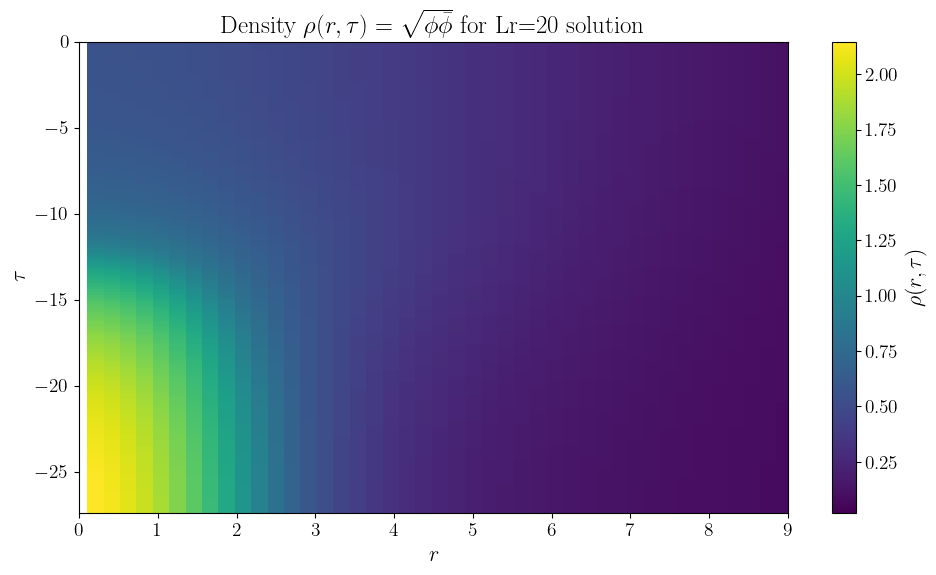

In [6]:
# Plot the solution: density rho = sqrt((phi * phibar).real) 
import matplotlib.pyplot as plt 
 
solution_plot = solution_Lr20 
grid_plot = solution_plot.grid 
 
# Compute rho from phi and phibar 
rho_2d = np.sqrt( 
 np.maximum( 
 (solution_plot.phi * solution_plot.phibar).real, 
 0.0, 
) 
) 
 
# Create meshgrid for plotting 
R_plot, T_plot = np.meshgrid(grid_plot.r, grid_plot.tau, indexing="xy") 
 
# Plot 2D density 
fig, ax = plt.subplots(figsize=(10, 6)) 
cf = ax.pcolormesh(R_plot, T_plot, rho_2d.T, shading="auto", cmap="viridis") 
ax.set_xlabel(r"$r$") 
ax.set_ylabel(r"$\tau$") 
ax.set_xlim(0, 9)
ax.set_title(r"Density $\rho(r, \tau) = \sqrt{\phi \bar{\phi}}$ for Lr=20 solution") 
fig.colorbar(cf, ax=ax, label=r"$\rho(r, \tau)$") 
plt.tight_layout() 
plt.show() 

In [7]:
# Plot all snapshots from solution_beta_eta
#plot_newton_snapshots(snapshot_dir_ref)

In [8]:
# --- Eta scan starting from Lr=20 solution --- 
x0_Lr20_for_scan = pack_fields(solution_Lr20.y, solution_Lr20.ybar) 
 
result_Lr20_eta = scan_eta_to_match_charge( 
 params, 
 omega_qball, 
 qcloud_profile, 
 unstable_mode, 
 settings=settings_Lr20, 
 eta_start=eta_start_ref, 
 target_charge=g2Q_target, 
 d_eta=0.1, 
 max_scan_steps=30, 
 tol=1e-4, 
 verbose=True, 
 x0_initial=x0_Lr20_for_scan, 
) 
 
print(f"\n--- Eta scan result with Lr=20 ---") 
print(f"η* = {result_Lr20_eta.eta:.6f}") 
print(f"Charge () = {result_Lr20_eta.solution.charge:.6f} (target: {g2Q_target:.6f}, ratio: {result_Lr20_eta.solution.charge/g2Q_target:.6f})") 
# Energy from at slice i=0 
if result_Lr20_eta.solution.energy is not None: 
    print(f"Energy ( τ≈0) = {result_Lr20_eta.solution.energy:.6f}") 
if result_Lr20_eta.solution.energy_ratio is not None: 
    print(f"Energy ratio () = {result_Lr20_eta.solution.energy_ratio:.6f}")

[Newton-explicit] iter=01, ||F||=1.504e-11, charge=4.736801e+02
[eta-scan] eta = 6.306313, charge = 4.736801e+02, target = 3.529285e+02, ratio = 1.342142
[eta-scan] try eta = 6.206313, charge = 4.411635e+02, ratio = 1.250008
[eta-scan] try eta = 6.106313, charge = 4.177781e+02, ratio = 1.183747
[eta-scan] try eta = 6.006313, charge = 4.001004e+02, ratio = 1.133659
[eta-scan] try eta = 5.906313, charge = 3.861621e+02, ratio = 1.094165
[eta-scan] try eta = 5.806313, charge = 3.747510e+02, ratio = 1.061833
[eta-scan] try eta = 5.706313, charge = 3.650707e+02, ratio = 1.034404
[eta-scan] try eta = 5.606313, charge = 3.565567e+02, ratio = 1.010280
[eta-scan] try eta = 5.506313, charge = 3.487619e+02, ratio = 0.988194
[eta-root] eta = 5.606313 (cached), charge = 3.565567e+02, ratio = 1.010280
[eta-root] eta = 5.506313 (cached), charge = 3.487619e+02, ratio = 0.988194
[eta-root] eta = 5.559766, charge = 3.528643e+02, ratio = 0.999818
[eta-root] eta = 5.560575, charge = 3.529274e+02, ratio = 0

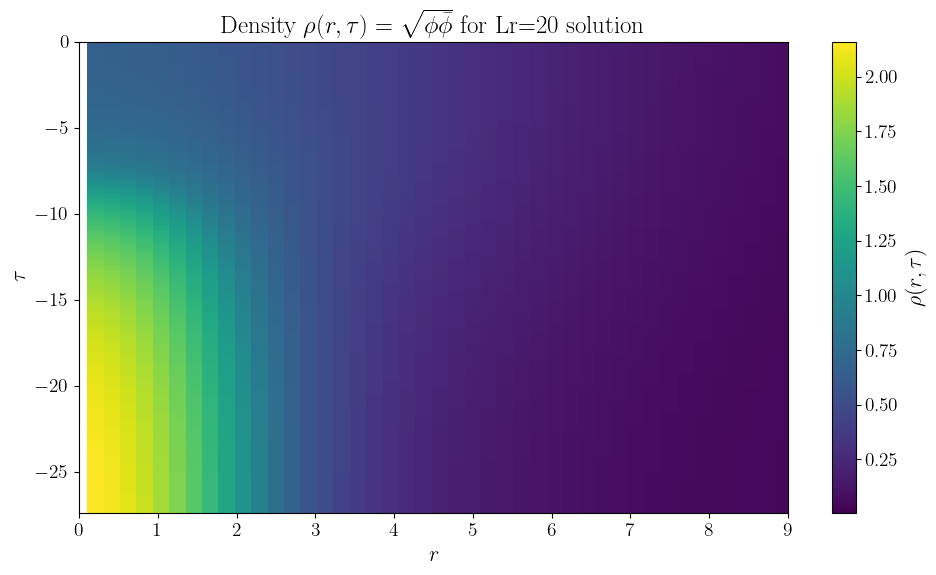

In [9]:
# Plot the solution: density rho = sqrt((phi * phibar).real) 
import matplotlib.pyplot as plt 
 
solution_plot = result_Lr20_eta.solution 
grid_plot = solution_plot.grid 
 
# Compute rho from phi and phibar 
rho_2d = np.sqrt( 
 np.maximum( 
 (solution_plot.phi * solution_plot.phibar).real, 
 0.0, 
) 
) 
 
# Create meshgrid for plotting 
R_plot, T_plot = np.meshgrid(grid_plot.r, grid_plot.tau, indexing="xy") 
 
# Plot 2D density 
fig, ax = plt.subplots(figsize=(10, 6)) 
cf = ax.pcolormesh(R_plot, T_plot, rho_2d.T, shading="auto", cmap="viridis") 
ax.set_xlabel(r"$r$") 
ax.set_ylabel(r"$\tau$") 
ax.set_xlim(0, 9)
ax.set_title(r"Density $\rho(r, \tau) = \sqrt{\phi \bar{\phi}}$ for Lr=20 solution") 
fig.colorbar(cf, ax=ax, label=r"$\rho(r, \tau)$") 
plt.tight_layout() 
plt.show() 

## Save ansatz for the starting point

In [ ]:

# Save the solution as ansatz for beta ~55
ansatz_solution_beta_55 = result_Lr20_eta.solution
ansatz_save_path = PROJECT_ROOT / "Q_ball_finder" / "data" / "ansatz_solution_beta_55.npz"
ansatz_save_path.parent.mkdir(parents=True, exist_ok=True)

np.savez(
    ansatz_save_path,
    r=ansatz_solution_beta_55.grid.r,
    tau=ansatz_solution_beta_55.grid.tau,
    y=ansatz_solution_beta_55.y,
    ybar=ansatz_solution_beta_55.ybar,
    phi=ansatz_solution_beta_55.phi,
    phibar=ansatz_solution_beta_55.phibar,
    beta=ansatz_solution_beta_55.settings.beta,
    eta=result_Lr20_eta.eta,
    charge=ansatz_solution_beta_55.charge,
    energy=ansatz_solution_beta_55.energy,
    energy_ratio=ansatz_solution_beta_55.energy_ratio,
)

print(f"\n--- Ansatz saved ---")
print(f"Saved to: {ansatz_save_path}")
print(f"Beta = {ansatz_solution_beta_55.settings.beta:.6f}")
print(f"Nr = {ansatz_solution_beta_55.grid.Nr}, Ntau = {ansatz_solution_beta_55.grid.Ntau}")
print(f"Lr = {ansatz_solution_beta_55.settings.Lr}")

In [15]:
# Load saved ansatz from beta ~55 and solve for beta=60
from Q_ball_finder.ansatz import AnsatzResult
from Q_ball_finder.notebook_utils import resample_ansatz

# Load the saved ansatz
ansatz_load_path = PROJECT_ROOT / "Q_ball_finder" / "data" / "ansatz_solution_beta_55.npz"
ansatz_data = np.load(ansatz_load_path)

print(f"Loaded ansatz from: {ansatz_load_path}")
print(f"Original beta: {ansatz_data['beta']:.6f}")
print(f"Original Nr: {len(ansatz_data['r'])}, Ntau: {len(ansatz_data['tau'])}")

# Build grid for beta=60 (using same Nr, Ntau, Lr as the saved solution)
beta_new = 80.0
Nr_new = len(ansatz_data['r'])
Ntau_new = len(ansatz_data['tau'])
Lr_new = ansatz_data['r'].max()  # Approximate Lr from saved grid
grid_new = build_grid(Nr=Nr_new, Ntau=Ntau_new, Lr=Lr_new, beta=beta_new)

print(f"\nNew grid: beta={beta_new:.6f}, Nr={Nr_new}, Ntau={Ntau_new}, Lr={Lr_new:.6f}")

# Create AnsatzResult from loaded data
# First, need to build old grid from saved data
grid_old = build_grid(Nr=Nr_new, Ntau=Ntau_new, Lr=Lr_new, beta=float(ansatz_data['beta']))

ansatz_old = AnsatzResult(
    phi=ansatz_data['phi'],
    phibar=ansatz_data['phibar'],
    y=ansatz_data['y'],
    ybar=ansatz_data['ybar'],
)

# Resample ansatz onto new grid (beta=60)
ansatz_new = resample_ansatz(
    ansatz_old,
    grid_old,
    grid_new,
    omega=omega_qball,
    resample_phi_directly=False,
    clamp_tau_to_plateau=True,
)

# Pack into x0_initial
x0_from_ansatz = pack_fields(ansatz_new.y, ansatz_new.ybar)

# Settings for beta=60
settings_beta60 = QBall2DSettings(
    beta=beta_new,
    ansatz_amplitude=2.5,  # not used when x0 provided
    energy_reference=E_Q,
    omega_tilde=omega_cloud,
    Nr=Nr_new,
    Ntau=Ntau_new,
    Lr=Lr_new,
    newton_verbose=True,
)

# Initial eta for beta=60: use the eta from the saved ansatz
eta_start_beta60 = float(ansatz_data['eta'])

# Solve with fixed beta and eta
solution_beta60, charge_beta60, x0_beta60 = solve_fixed_beta_eta(
    params,
    omega_qball,
    qcloud_profile,
    unstable_mode,
    settings=settings_beta60,
    eta=eta_start_beta60,
    x0_initial=x0_from_ansatz,
    verbose=True,
)

print(f"\nSolution with beta={beta_new:.6f}:")
print(f"  Charge = {charge_beta60:.6f} (ratio {charge_beta60 / g2Q_target:.6f})")
if solution_beta60.energy is not None:
    print(f"  Energy (τ≈0) = {solution_beta60.energy:.6f}")
    if solution_beta60.energy_ratio is not None:
        print(f"  Energy ratio = {solution_beta60.energy_ratio:.6f}")

# Now scan eta to match target charge
result_beta60_eta = scan_eta_to_match_charge(
    params,
    omega_qball,
    qcloud_profile,
    unstable_mode,
    settings=settings_beta60,
    eta_start=eta_start_beta60,
    target_charge=g2Q_target,
    d_eta=0.1,
    max_scan_steps=30,
    tol=1e-4,
    verbose=True,
    x0_initial=x0_beta60,
)

print(f"\n--- Eta scan result with beta={beta_new:.6f} ---")
print(f"η* = {result_beta60_eta.eta:.6f}")
print(f"Charge = {result_beta60_eta.solution.charge:.6f} (target: {g2Q_target:.6f}, ratio: {result_beta60_eta.solution.charge/g2Q_target:.6f})")
if result_beta60_eta.solution.energy is not None:
    print(f"Energy (τ≈0) = {result_beta60_eta.solution.energy:.6f}")
if result_beta60_eta.solution.energy_ratio is not None:
    print(f"Energy ratio = {result_beta60_eta.solution.energy_ratio:.6f}")

Loaded ansatz from: /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Q_ball_finder/data/ansatz_solution_beta_55.npz
Original beta: 54.800000
Original Nr: 96, Ntau: 162

New grid: beta=80.000000, Nr=96, Ntau=162, Lr=20.000000
[Newton-explicit] iter=01, ||F||=7.641e+01, charge=3.529844e+02
[Newton-explicit] iter=02, ||F||=2.182e+03, charge=4.946324e+02
[Newton-explicit] iter=03, ||F||=2.635e+03, charge=2.370387e+02
[Newton-explicit] iter=04, ||F||=8.506e+03, charge=1.272582e+03
[Newton-explicit] iter=05, ||F||=1.199e+04, charge=9.012370e+02
[Newton-explicit] iter=06, ||F||=9.383e+03, charge=4.225524e+02
[Newton-explicit] iter=07, ||F||=4.936e+03, charge=4.728083e+02
[Newton-explicit] iter=08, ||F||=1.622e+04, charge=1.066449e+03
[Newton-explicit] iter=09, ||F||=5.070e+05, charge=6.918714e+04
[Newton-explicit] iter=10, ||F||=2.761e+05, charge=1.103288e+07
[Newton-explicit] iter=11, ||F||=6.534e+05, charge=1.515010e+08
[Newton-explicit] iter=12, ||F||=6.726e+06, charge=3.

KeyboardInterrupt: 

## Scan Q-ball branch for $\beta \to \infty$

In [15]:
# --- Beta scan with dtau-fixed grids and proper warm starts --- 

# Reference values for dtau calculation 
beta_ref_scan = beta_ref # Use the same beta_ref from above 
ntau_ref_scan = 48 * 2 #300 # Use fixed Ntau=300 for beta scan
nr_ref_scan = 81 * 2 #150 # Use fixed Nr=150 for beta scan
lr_ref_scan = 20.0 # Paper default Lr=20.0 (can override with Lr_ref if needed) 

# Beta scan parameters - use small steps for continuation 
beta_step = 5 # Small step for continuation (0.2-0.5 recommended) 
num_steps = 25 # Number of steps 
beta_start = beta_ref 
beta_values_scan = beta_start + beta_step * np.arange(num_steps + 1) 

# Choose whether to adjust Ntau to keep dtau constant or keep Ntau constant
adjust_ntau_for_constant_dtau = True  # Set to False to keep Ntau constant

# Storage 
eta_values_scan = [] 
energy_ratios_scan = [] 
energy_values = [] 
energy_tau0_values = []  # Energy at tau=0 (ghost reconstruction)
energy_ratios_tau0_scan = []  # Energy ratio at tau=0
solutions_scan = [] 
ntau_values = [] 
dtau_values = [] 
charge_values = [] 

# Start from the Lr=20 eta scan result 
solution_original = result_Lr20_eta.solution 
eta_current = result_Lr20_eta.eta 

# Resample the initial solution onto the new grid (Nr=150, Ntau=300)
# This ensures the first step uses the resampled solution as ansatz
from Q_ball_finder.ansatz import AnsatzResult
from Q_ball_finder.bounce2d import QBall2DSolution
from Q_ball_finder.diagnostics import compute_energy_tau0_ghost

grid_ref_scan = build_grid(nr_ref_scan, ntau_ref_scan, lr_ref_scan, beta_ref_scan)
ansatz_resampled = resample_ansatz(
    AnsatzResult(
        phi=solution_original.phi,
        phibar=solution_original.phibar,
        y=solution_original.y,
        ybar=solution_original.ybar,
    ),
    solution_original.grid,
    grid_ref_scan,
    omega=omega_qball,
    resample_phi_directly=False,
    clamp_tau_to_plateau=True,
)

# Create new solution object with resampled fields
# Use original solution's profile, unstable_mode, ansatz, and newton as placeholders
# (they won't be used in warm_start_from_solution, only y/ybar/phi/phibar/grid are needed)
solution_current = QBall2DSolution(
    y=ansatz_resampled.y,
    ybar=ansatz_resampled.ybar,
    phi=ansatz_resampled.phi,
    phibar=ansatz_resampled.phibar,
    grid=grid_ref_scan,
    settings=solution_original.settings,
    profile=solution_original.profile,
    unstable_mode=solution_original.unstable_mode,
    ansatz=solution_original.ansatz,
    newton=solution_original.newton,
)

for idx, beta_i in enumerate(beta_values_scan): 
    print(f"\n{'='*60}")
    print(f"Beta scan step {idx+1}/{len(beta_values_scan)}: β = {beta_i:.4f}")
    print(f"{'='*60}")

    # Compute Ntau: either adjust to keep dtau constant, or keep constant
    if adjust_ntau_for_constant_dtau:
        # Adjust Ntau for this beta to keep dtau approximately constant
        ntau_i = compute_ntau_for_beta(beta_i, beta_ref_scan, ntau_ref_scan, min_ntau=100)
        dtau_i = beta_i / (2.0 * ntau_i)
        print(f"Strategy: Adjusting Ntau to keep dtau constant")
    else:
        # Keep Ntau constant (use reference value)
        ntau_i = ntau_ref_scan
        dtau_i = beta_i / (2.0 * ntau_i)
        print(f"Strategy: Keeping Ntau constant")

    print(f"Ntau = {ntau_i}, dtau = {dtau_i:.6f}")

    # Build grid for this beta
    grid_i = build_grid(nr_ref_scan, ntau_i, lr_ref_scan, beta_i)
 
    # Prepare warm start: ALWAYS resample to handle grid differences (e.g., Lr changes)
    # Uses proper resampling with tau clamping and plateau enforcement
    x0_current = warm_start_from_solution(
    solution_current,
    grid_i,
    omega_qball, # Required for reconstructing phi/phibar from y/ybar
    enforce_plateau=True,
    ) 
 
    # Settings for this beta    
    settings_i = QBall2DSettings(
    beta=beta_i,
    ansatz_amplitude=0.8,
    energy_reference=E_Q,
    omega_tilde=omega_cloud,
    Nr=nr_ref_scan,
    Ntau=ntau_i,
    Lr=lr_ref_scan,
    newton_verbose=True,
    )
 
    # Use eta* from previous step as starting point
    eta_start_i = eta_current
 
    # Run eta scan
    result_i = scan_eta_to_match_charge(
    params,
    omega_qball,
    qcloud_profile,
    unstable_mode,
    settings=settings_i,
    eta_start=eta_start_i,
    target_charge=g2Q_target,
    d_eta=0.05,
    max_scan_steps=30,
    tol=1e-4,
    verbose=True,
    x0_initial=x0_current,
    )
    # Store results 
    eta_values_scan.append(result_i.eta)
    solutions_scan.append(result_i)
    ntau_values.append(ntau_i)
    dtau_values.append(dtau_i)
    charge_values.append(result_i.solution.charge)
    
    # Store energy results (at slice i=0)
    if result_i.solution.energy is not None:
        energy_values.append(result_i.solution.energy)
        energy_ratios_scan.append(result_i.solution.energy_ratio)
    else:
        energy_values.append(None)
        energy_ratios_scan.append(None)
    
    # Compute and store energy at tau=0 (ghost reconstruction)
    try:
        E_tau0 = compute_energy_tau0_ghost(
            result_i.solution.y,
            result_i.solution.ybar,
            result_i.solution.grid,
            omega_qball,
            result_i.solution.settings.eta0,
            params,
        )
        energy_tau0_values.append(E_tau0)
        energy_ratios_tau0_scan.append(E_tau0 / E_Q)
    except Exception as e:
        print(f"Warning: Failed to compute energy at tau=0: {e}")
        energy_tau0_values.append(None)
        energy_ratios_tau0_scan.append(None)
    
    # Print diagnostics
    print(f"\n--- Diagnostics for β = {beta_i:.4f} ---")
    print(f"η* = {result_i.eta:.6f}")
    print(f"Q = {result_i.solution.charge:.6f} (target: {g2Q_target:.6f}, ratio: {result_i.solution.charge/g2Q_target:.6f})")
    print(f"Ntau = {ntau_i}, dtau = {dtau_i:.6f}")
    # Print energy (at slice i=0)
    if result_i.solution.energy is not None:
        print(f"Energy (τ≈0) = {result_i.solution.energy:.6f}")
        if result_i.solution.energy_ratio is not None:
            print(f"Energy ratio = {result_i.solution.energy_ratio:.6f}")
    # Print energy at tau=0 (ghost reconstruction)
    if energy_tau0_values[-1] is not None:
        print(f"Energy (τ=0, ghost) = {energy_tau0_values[-1]:.6f}")
        if energy_ratios_tau0_scan[-1] is not None:
            print(f"Energy ratio (τ=0, ghost) = {energy_ratios_tau0_scan[-1]:.6f}")
    
    # Update for next iteration: use eta* from current step as initial eta for next step
    # Save final solution after this step
    solution_save_dir = PROJECT_ROOT / "Q_ball_finder" / "data" / "beta_scan_solutions"
    solution_save_dir.mkdir(parents=True, exist_ok=True)
    solution_save_path = solution_save_dir / f"solution_beta_{beta_i:.4f}.npz"
    np.savez(
        solution_save_path,
        r=result_i.solution.grid.r,
        tau=result_i.solution.grid.tau,
        y=result_i.solution.y,
        ybar=result_i.solution.ybar,
        phi=result_i.solution.phi,
        phibar=result_i.solution.phibar,
        beta=result_i.solution.settings.beta,
        eta=result_i.eta,
        charge=result_i.solution.charge,
        energy=result_i.solution.energy,
        energy_ratio=result_i.solution.energy_ratio,
    )
    solution_current = result_i.solution
    eta_current = result_i.eta  # This will be used as eta_start_i in the next iteration

# Convert to arrays 
eta_values_scan = np.array(eta_values_scan) 



Beta scan step 1/26: β = 54.8000
Strategy: Adjusting Ntau to keep dtau constant
Ntau = 100, dtau = 0.274000
[Newton-explicit] iter=01, ||F||=3.965e+03, charge=3.533993e+02
[Newton-explicit] iter=02, ||F||=2.655e+01, charge=3.551951e+02
[Newton-explicit] iter=03, ||F||=2.633e-02, charge=3.543399e+02
[Newton-explicit] iter=04, ||F||=1.186e-06, charge=3.543415e+02
[Newton-explicit] iter=05, ||F||=1.022e-11, charge=3.543415e+02
[eta-scan] eta = 5.560575, charge = 3.543415e+02, target = 3.529285e+02, ratio = 1.004004
[eta-scan] try eta = 5.510575, charge = 3.504859e+02, ratio = 0.993079
[eta-root] eta = 5.560575 (cached), charge = 3.543415e+02, ratio = 1.004004
[eta-root] eta = 5.510575 (cached), charge = 3.504859e+02, ratio = 0.993079
[eta-root] eta = 5.542251, charge = 3.529157e+02, ratio = 0.999964
[eta-root] eta = 5.542578, charge = 3.529410e+02, ratio = 1.000036
[eta-scan] eta* = 5.542578, charge = 3.529410e+02, ratio = 1.000036
[eta-scan] energy(τ≈0) = 3.660299e+02, energy/E_Q = 1.00

/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Q_ball_finder/nr_solver.py:77: RuntimeWarning: invalid value encountered in multiply
  x = x + step * delta
/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Q_ball_finder/bounce2d.py:141: RuntimeWarning: overflow encountered in multiply
  s = (phi * phibar).real
/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2790: RuntimeWarning: overflow encountered in dot
  sqnorm = x_real.dot(x_real) + x_imag.dot(x_imag)
/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Q_ball_finder/bounce2d.py:212: RuntimeWarning: overflow encountered in multiply
  s = (phi * phibar).real
/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Q_ball_finder/bounce2d.py:305: RuntimeWarning: overflow encountered in scalar multiply
  - y_val * dV_dy
/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Q_ball_finder

 ** On entry to ZTRSV  parameter number  6 had an illegal value
 ** On entry to ZGEMV  parameter number  2 had an illegal value


/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Q_ball_finder/nr_solver.py:31: MatrixRankWarning: Matrix is exactly singular
  return spsolve(sp.csc_matrix(A), b)


[eta-root] eta = 7.188677, charge = nan, ratio = nan


/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Q_ball_finder/potentials.py:61: RuntimeWarning: invalid value encountered in logaddexp
  return -(m * m * v * v / b) * np.logaddexp(z, logc)


ValueError: The function value at x=7.188676526978045 is NaN; solver cannot continue.

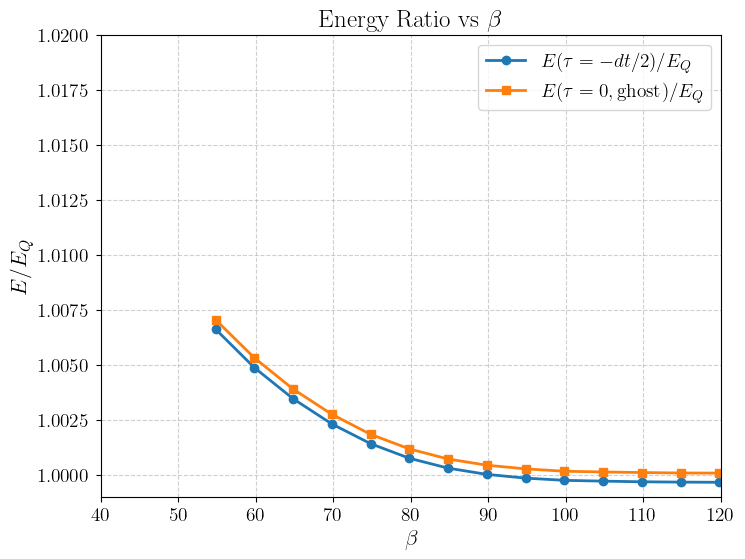

In [ ]:
# --- Plot diagnostics from beta scan --- 
 
# Remove NaN values before plotting 
beta_values_plot = np.asarray(beta_values_scan) 
energy_ratios_plot = np.asarray(energy_ratios_scan) 
energy_ratios_tau0_plot = np.asarray(energy_ratios_tau0_scan) 
min_len = min(len(beta_values_plot), len(energy_ratios_plot), len(energy_ratios_tau0_plot)) 
beta_values_plot = beta_values_plot[:min_len] 
energy_ratios_plot = energy_ratios_plot[:min_len] 
energy_ratios_tau0_plot = energy_ratios_tau0_plot[:min_len] 
 
mask = ~np.isnan(energy_ratios_plot) 
mask_tau0 = ~np.isnan(energy_ratios_tau0_plot) 
beta_plot = beta_values_plot[mask] 
energy_ratios_plot_clean = energy_ratios_plot[mask] 
beta_plot_tau0 = beta_values_plot[mask_tau0] 
energy_ratios_tau0_plot_clean = energy_ratios_tau0_plot[mask_tau0] 
 
fig, ax = plt.subplots(figsize=(8, 6)) 
ax.plot(beta_plot, energy_ratios_plot_clean, marker="o", lw=2, markersize=6, label=r"$E(\tau=-dt/2)/E_Q$") 
ax.plot(beta_plot_tau0, energy_ratios_tau0_plot_clean, marker="s", lw=2, markersize=6, label=r"$E(\tau=0, \text{ghost})/E_Q$") 
ax.set_xlabel(r"$\beta$") 
ax.set_ylabel(r"$E/E_Q$") 
ax.set_ylim(0.999, 1.02)
ax.set_xlim(40, 120)
ax.set_title(r"Energy Ratio vs $\beta$") 
ax.grid(True, ls="--", alpha=0.6) 
ax.legend()
 
plt.show() 

In [ ]:


# Save the solution as ansatz for beta ~55
Qball_solution_Q_353 = solutions_scan[-1].solution
Qball_solution_Q_353_save_path = PROJECT_ROOT / "Q_ball_finder" / "data" / "Qball_solution_Q_353.npz"
Qball_solution_Q_353_save_path.parent.mkdir(parents=True, exist_ok=True)

np.savez(
    Qball_solution_Q_353_save_path,
    r=Qball_solution_Q_353.grid.r,
    tau=Qball_solution_Q_353.grid.tau,
    y=Qball_solution_Q_353.y,
    ybar=Qball_solution_Q_353.ybar,
    phi=Qball_solution_Q_353.phi,
    phibar=Qball_solution_Q_353.phibar,
    beta=Qball_solution_Q_353.settings.beta,
    eta=solutions_scan[-1].eta,
    charge=Qball_solution_Q_353.charge,
    energy=Qball_solution_Q_353.energy,
    energy_ratio=Qball_solution_Q_353.energy_ratio,
)

print(f"\n--- Ansatz saved ---")
print(f"Saved to: {Qball_solution_Q_353_save_path}")
print(f"Beta = {Qball_solution_Q_353.settings.beta:.6f}")
print(f"Nr = {Qball_solution_Q_353.grid.Nr}, Ntau = {Qball_solution_Q_353.grid.Ntau}")
print(f"Lr = {Qball_solution_Q_353.settings.Lr}")

NameError: name 'solutions_scan' is not defined

In [ ]:
# --- Plot: Q-ball, Q-cloud, and 2D solution slice at tau_min for saved solution --- 
from Q_ball_finder.diagnostics import compute_energy_tau0_ghost

solution_plot_last = Qball_solution_Q_353 
grid_plot_last = solution_plot_last.grid 
r_slice_last = grid_plot_last.r
tau_grid = grid_plot_last.tau

# Find tau with minimum index (tau_min) 
tau_idx_min_last = int(np.argmin(tau_grid)) 
tau_min_last = tau_grid[tau_idx_min_last] 

# Find indices closest to tau=-20, -15
tau_targets = [-20.0, -15.0]
tau_indices = {}
tau_values = {}
for tau_target in tau_targets:
    idx = int(np.argmin(np.abs(tau_grid - tau_target)))
    tau_indices[tau_target] = idx
    tau_values[tau_target] = tau_grid[idx]

# Extract slices from 2D solution
def extract_rho_slice(phi_slice, phibar_slice):
    return np.sqrt(np.maximum((phi_slice * phibar_slice).real, 0.0))

rho_slice_tau_min = extract_rho_slice(
    solution_plot_last.phi[:, tau_idx_min_last],
    solution_plot_last.phibar[:, tau_idx_min_last]
)

rho_slice_tau_m20 = extract_rho_slice(
    solution_plot_last.phi[:, tau_indices[-20.0]],
    solution_plot_last.phibar[:, tau_indices[-20.0]]
)

rho_slice_tau_m15 = extract_rho_slice(
    solution_plot_last.phi[:, tau_indices[-15.0]],
    solution_plot_last.phibar[:, tau_indices[-15.0]]
)

# Reconstruct rho at tau=0 using ghost reconstruction
y_tau0 = 0.5 * (solution_plot_last.ybar[:, 0] + solution_plot_last.y[:, 0])
ybar_tau0 = 0.5 * (solution_plot_last.y[:, 0] + solution_plot_last.ybar[:, 0])
phi_tau0 = y_tau0 / r_slice_last
phibar_tau0 = ybar_tau0 / r_slice_last
rho_slice_tau0 = extract_rho_slice(phi_tau0, phibar_tau0)

# Interpolate 1D profiles onto the same r grid 
rho_qball_interp_last = np.interp(r_slice_last, qball_profile.r, qball_profile.phi_abs) 
rho_qcloud_interp_last = np.interp(r_slice_last, qcloud_profile.r, qcloud_profile.phi_abs) 
 
# Plot 
fig, ax = plt.subplots(figsize=(9, 6)) 

# 2D slices: solid lines
ax.plot(r_slice_last, rho_slice_tau_min, lw=2.0, linestyle="-", label=rf"$m\tau = {tau_min_last:.2f}$") 
ax.plot(r_slice_last, rho_slice_tau_m20, lw=2.0, linestyle="-", label=rf"$m\tau = {tau_values[-20.0]:.2f}$") 
ax.plot(r_slice_last, rho_slice_tau_m15, lw=2.0, linestyle="-", label=rf"$m\tau = {tau_values[-15.0]:.2f}$") 
ax.plot(r_slice_last, rho_slice_tau0, lw=2.0, linestyle="-", label=r"$m\tau = 0$") 

# 1D profiles: scatter plot with equally spaced points
# Select equally spaced indices
n_points = 60  # Number of points to show
indices = np.linspace(0, len(r_slice_last)-1, n_points, dtype=int)
ax.scatter(r_slice_last[indices], rho_qball_interp_last[indices], 
          marker="o", s=40, facecolors='white', edgecolors='black', linewidths=1.5,
          label=rf"1D Q-ball $|\varphi(r)|$", zorder=5)
ax.scatter(r_slice_last[indices], rho_qcloud_interp_last[indices], 
          marker="o", s=40, facecolors='blue', alpha=0.5, edgecolors='black', linewidths=1.5,
          label=rf"1D Q-cloud $|\varphi(r)|$", zorder=5) 
ax.set_xlabel(r"$mr$", fontsize=18) 
ax.set_ylabel(r"$\rho(r)$", fontsize=18) 
ax.set_xlim(0, min(10, np.max(r_slice_last))) 
ax.set_title(rf"$mL_r=20$, $m\beta = {solution_plot_last.settings.beta:.2f}$, $\eta^* = {solution_plot_last.settings.eta0:.3f}$") 
ax.grid(True, ls="--", alpha=0.6) 
ax.legend() 

# Save to PDF
pdf_path = PROJECT_ROOT / "Q_ball_finder" / "notebooks" / "slices_solutions.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
print(f"Plot saved to: {pdf_path}")

plt.show() 

NameError: name 'Qball_solution_Q_353' is not defined

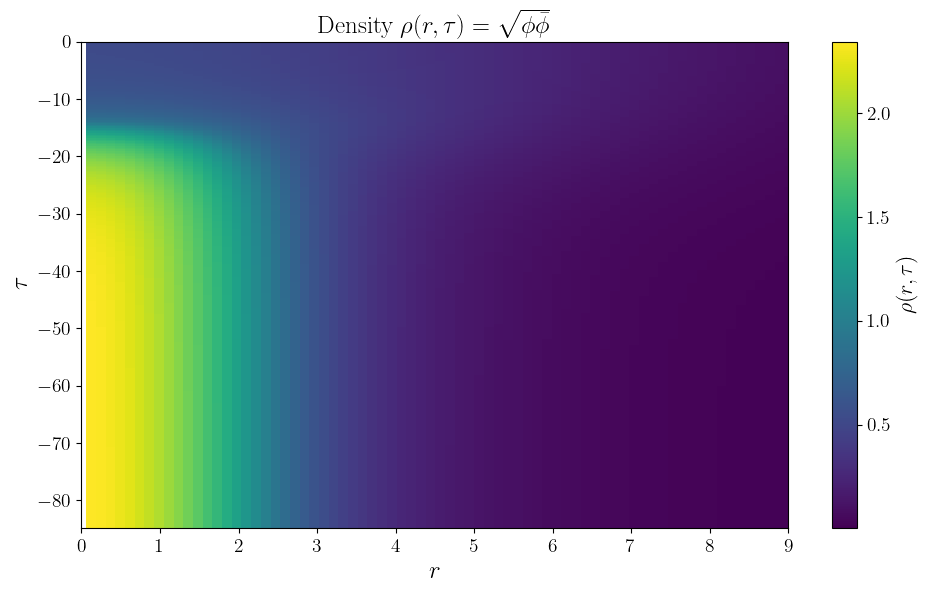

In [ ]:
# Plot the solution: density rho = sqrt((phi * phibar).real) 
import matplotlib.pyplot as plt 
 
solution_plot = solution_plot_last 
grid_plot = solution_plot.grid 
 
# Compute rho from phi and phibar 
rho_2d = np.sqrt( 
 np.maximum( 
 (solution_plot.phi * solution_plot.phibar).real, 
 0.0, 
) 
) 
 
# Create meshgrid for plotting 
R_plot, T_plot = np.meshgrid(grid_plot.r, grid_plot.tau, indexing="xy") 
 
# Plot 2D density 
fig, ax = plt.subplots(figsize=(10, 10/1.618)) 
cf = ax.pcolormesh(R_plot, T_plot, rho_2d.T, shading="auto", cmap="viridis") 
ax.set_xlabel(r"$r$", fontsize=18) 
ax.set_ylabel(r"$\tau$", fontsize=18)
ax.set_xlim(0, 9)
ax.set_title(r"Density $\rho(r, \tau) = \sqrt{\phi \bar{\phi}}$") 
fig.colorbar(cf, ax=ax, label=r"$\rho(r, \tau)$") 
plt.tight_layout() 
plt.show() 

Plot saved to: /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Q_ball_finder/notebooks/3D_solution.pdf


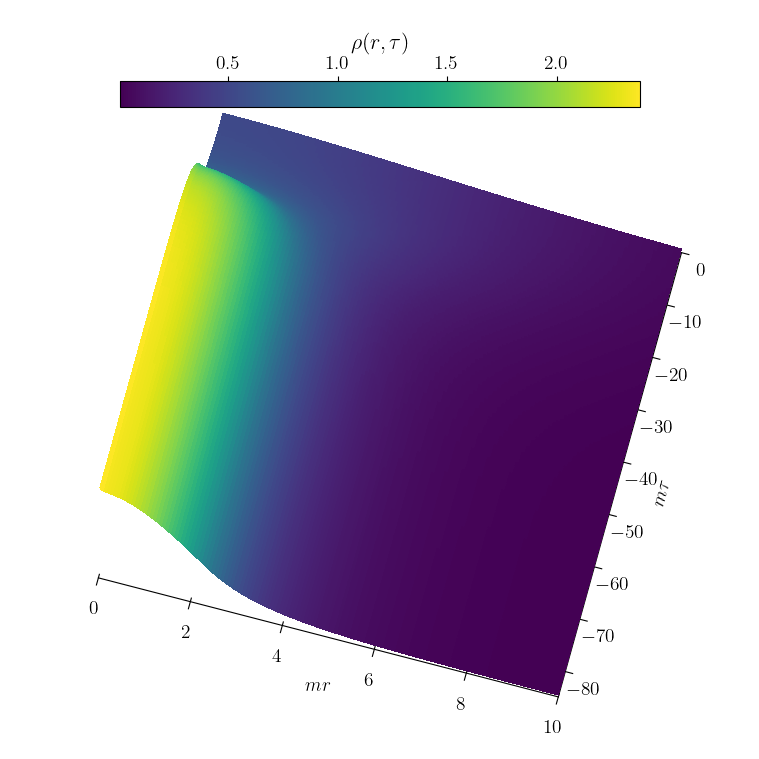

In [ ]:
# Resample solution to finer grid with interpolation (no fill_value=0.0) and plot as 3D
from scipy.interpolate import RegularGridInterpolator
from mpl_toolkits.mplot3d import Axes3D
from Q_ball_finder.grid import phi_from_y, phi_from_ybar

# Original solution
solution_orig = solution_plot_last
grid_orig = solution_orig.grid

# Create finer grid: stop at r=10, use finer resolution
Lr_fine = 10.0  # Ensure solution stops at r=10
Nr_fine = 300  # Double the resolution in r
Ntau_fine = 600  # Double the resolution in tau
beta_fine = solution_orig.settings.beta

grid_fine = build_grid(Nr=Nr_fine, Ntau=Ntau_fine, Lr=Lr_fine, beta=beta_fine)

# Custom resampling with extrapolation instead of fill_value=0.0
r_old, tau_old = grid_orig.r, grid_orig.tau
r_new, tau_new = grid_fine.r, grid_fine.tau

# Resample y and ybar with extrapolation
def resample_with_extrapolation(field_old, r_old, tau_old, r_new, tau_new):
    """Resample field with linear extrapolation instead of fill_value=0.0"""
    R_new, T_new = np.meshgrid(r_new, tau_new, indexing="ij")
    points_new = np.stack([R_new, T_new], axis=-1)
    
    # Use method='linear' with bounds_error=False but extrapolate using nearest neighbor
    # For extrapolation, we'll use the boundary values
    interp_re = RegularGridInterpolator(
        (r_old, tau_old), np.real(field_old), 
        bounds_error=False, 
        fill_value=None,  # This enables extrapolation
        method='linear'
    )
    interp_im = RegularGridInterpolator(
        (r_old, tau_old), np.imag(field_old),
        bounds_error=False,
        fill_value=None,  # This enables extrapolation
        method='linear'
    )
    
    # For points outside bounds, extrapolate using boundary values
    field_new = interp_re(points_new) + 1j * interp_im(points_new)
    
    # Clamp tau to plateau if needed
    mask_tau_out = (T_new < tau_old.min()) | (T_new > tau_old.max())
    if np.any(mask_tau_out):
        # For tau beyond bounds, use the boundary slice
        tau_clamped = np.clip(T_new, tau_old.min(), tau_old.max())
        points_clamped = np.stack([R_new, tau_clamped], axis=-1)
        field_clamped = interp_re(points_clamped) + 1j * interp_im(points_clamped)
        field_new[mask_tau_out] = field_clamped[mask_tau_out]
    
    return field_new

# Resample y and ybar
y_new = resample_with_extrapolation(solution_orig.y, r_old, tau_old, r_new, tau_new)
ybar_new = resample_with_extrapolation(solution_orig.ybar, r_old, tau_old, r_new, tau_new)

# Reconstruct phi/phibar from resampled y/ybar
phi_new = phi_from_y(y_new, grid_fine, omega_qball)
phibar_new = phi_from_ybar(ybar_new, grid_fine, omega_qball)

# Compute rho from resampled phi and phibar
rho_fine = np.sqrt(
    np.maximum(
        (phi_new * phibar_new).real,
        0.0,
    )
)

# Filter out r=0: keep only r > 0
mask_r_positive = grid_fine.r > 0
r_plot = grid_fine.r[mask_r_positive]
rho_plot = rho_fine[mask_r_positive, :]

# Create meshgrid for 3D plotting (excluding r=0)
R_3d, T_3d = np.meshgrid(r_plot, grid_fine.tau, indexing="xy")

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot surface (no grid lines on surface)
surf = ax.plot_surface(R_3d, T_3d, rho_plot.T, cmap='viridis', 
                       linewidth=0, antialiased=False, alpha=1, edgecolor='none', shade=False,rcount=200, ccount=200)

# Set labels
ax.set_xlabel(r"$mr$", fontsize=14)
ax.set_ylabel(r"$m\tau$", fontsize=14)

# Completely remove z-axis
ax.set_zlabel("")
ax.set_zticks([])
ax.set_zticklabels([])
ax.zaxis.line.set_linewidth(0.0)
ax.zaxis.pane.set_visible(False)
ax.zaxis.set_visible(False)   # hides axis ticks/labels

# Remove all panes (walls) of the 3D box
ax.xaxis.pane.set_visible(False)
ax.yaxis.pane.set_visible(False)
ax.zaxis.pane.set_visible(False)

# Remove grid on axes
ax.grid(False)

# Set limits: ensure x starts > 0 and stops at 10
ax.set_xlim(0*r_plot.min(), min(10.0, r_plot.max()))
ax.set_ylim(grid_fine.tau.min(), 0)

# Add colorbar (closer to plot with smaller pad)
cbar = fig.colorbar(surf, ax=ax, orientation="horizontal",
    location="top", shrink=0.45, aspect=20, pad=-0.13, label=r"$\rho(r, \tau)$")

#ax.set_title(r"Density $\rho(r, \tau) = \sqrt{\phi \bar{\phi}}$ (resampled, fine grid, r>0)")
ax.set_proj_type("ortho")


ax.view_init(elev=75, azim=-75)  # vicino a 90 evita disallineamenti


plt.tight_layout()
# Save to PDF
pdf_path = PROJECT_ROOT / "Q_ball_finder" / "notebooks" / "3D_solution.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
print(f"Plot saved to: {pdf_path}")
plt.show()

## Scan Q-ball branch $\beta \to 0$

In [20]:
# --- Beta scan with dtau-fixed grids and proper warm starts --- 

# Reference values for dtau calculation 
beta_ref_scan = beta_ref # Use the same beta_ref from above 
ntau_ref_scan = 48 * 2 #300 # Use fixed Ntau=300 for beta scan
nr_ref_scan = 81 * 2 #150 # Use fixed Nr=150 for beta scan
lr_ref_scan = 20.0 # Paper default Lr=20.0 (can override with Lr_ref if needed) 

# Beta scan parameters - use small steps for continuation 
beta_step = 0.5 # Small step for continuation (0.2-0.5 recommended) 
num_steps = 30 # Number of steps 
beta_start = beta_ref 
beta_values_scan = beta_start - beta_step * np.arange(num_steps + 1) 

# Choose whether to adjust Ntau to keep dtau constant or keep Ntau constant
adjust_ntau_for_constant_dtau = True  # Set to False to keep Ntau constant

# Storage 
eta_values_scan = [] 
energy_ratios_scan = [] 
energy_values = [] 
energy_tau0_values = []  # Energy at tau=0 (ghost reconstruction)
energy_ratios_tau0_scan = []  # Energy ratio at tau=0
solutions_scan = [] 
ntau_values = [] 
dtau_values = [] 
charge_values = [] 

# Start from the Lr=20 eta scan result 
solution_original = result_Lr20_eta.solution 
eta_current = result_Lr20_eta.eta 

# Resample the initial solution onto the new grid (Nr=150, Ntau=300)
# This ensures the first step uses the resampled solution as ansatz
from Q_ball_finder.ansatz import AnsatzResult
from Q_ball_finder.bounce2d import QBall2DSolution
from Q_ball_finder.diagnostics import compute_energy_tau0_ghost

grid_ref_scan = build_grid(nr_ref_scan, ntau_ref_scan, lr_ref_scan, beta_ref_scan)
ansatz_resampled = resample_ansatz(
    AnsatzResult(
        phi=solution_original.phi,
        phibar=solution_original.phibar,
        y=solution_original.y,
        ybar=solution_original.ybar,
    ),
    solution_original.grid,
    grid_ref_scan,
    omega=omega_qball,
    resample_phi_directly=False,
    clamp_tau_to_plateau=True,
)

# Create new solution object with resampled fields
# Use original solution's profile, unstable_mode, ansatz, and newton as placeholders
# (they won't be used in warm_start_from_solution, only y/ybar/phi/phibar/grid are needed)
solution_current = QBall2DSolution(
    y=ansatz_resampled.y,
    ybar=ansatz_resampled.ybar,
    phi=ansatz_resampled.phi,
    phibar=ansatz_resampled.phibar,
    grid=grid_ref_scan,
    settings=solution_original.settings,
    profile=solution_original.profile,
    unstable_mode=solution_original.unstable_mode,
    ansatz=solution_original.ansatz,
    newton=solution_original.newton,
)

for idx, beta_i in enumerate(beta_values_scan): 
    print(f"\n{'='*60}")
    print(f"Beta scan step {idx+1}/{len(beta_values_scan)}: β = {beta_i:.4f}")
    print(f"{'='*60}")

    # Compute Ntau: either adjust to keep dtau constant, or keep constant
    if adjust_ntau_for_constant_dtau:
        # Adjust Ntau for this beta to keep dtau approximately constant
        ntau_i = compute_ntau_for_beta(beta_i, beta_ref_scan, ntau_ref_scan, min_ntau=100)
        dtau_i = beta_i / (2.0 * ntau_i)
        print(f"Strategy: Adjusting Ntau to keep dtau constant")
    else:
        # Keep Ntau constant (use reference value)
        ntau_i = ntau_ref_scan
        dtau_i = beta_i / (2.0 * ntau_i)
        print(f"Strategy: Keeping Ntau constant")

    print(f"Ntau = {ntau_i}, dtau = {dtau_i:.6f}")

    # Build grid for this beta
    grid_i = build_grid(nr_ref_scan, ntau_i, lr_ref_scan, beta_i)
 
    # Prepare warm start: ALWAYS resample to handle grid differences (e.g., Lr changes)
    # Uses proper resampling with tau clamping and plateau enforcement
    x0_current = warm_start_from_solution(
    solution_current,
    grid_i,
    omega_qball, # Required for reconstructing phi/phibar from y/ybar
    enforce_plateau=True,
    ) 
 
    # Settings for this beta
    settings_i = QBall2DSettings(
    beta=beta_i,
    ansatz_amplitude=0.8,
    energy_reference=E_Q,
    omega_tilde=omega_cloud,
    Nr=nr_ref_scan,
    Ntau=ntau_i,
    Lr=lr_ref_scan,
    newton_verbose=True,
    ) 
 
    # Use eta* from previous step as starting point
    eta_start_i = eta_current
 
    # Run eta scan
    result_i = scan_eta_to_match_charge(
    params,
    omega_qball,
    qcloud_profile,
    unstable_mode,
    settings=settings_i,
    eta_start=eta_start_i,
    target_charge=g2Q_target,
    d_eta=0.05,
    max_scan_steps=30,
    tol=1e-4,
    verbose=True,
    x0_initial=x0_current,
    )
    # Store results 
    eta_values_scan.append(result_i.eta)
    solutions_scan.append(result_i)
    ntau_values.append(ntau_i)
    dtau_values.append(dtau_i)
    charge_values.append(result_i.solution.charge)
    
    # Store energy results (at slice i=0)
    if result_i.solution.energy is not None:
        energy_values.append(result_i.solution.energy)
        energy_ratios_scan.append(result_i.solution.energy_ratio)
    else:
        energy_values.append(None)
        energy_ratios_scan.append(None)
    
    # Compute and store energy at tau=0 (ghost reconstruction)
    try:
        E_tau0 = compute_energy_tau0_ghost(
            result_i.solution.y,
            result_i.solution.ybar,
            result_i.solution.grid,
            omega_qball,
            result_i.solution.settings.eta0,
            params,
        )
        energy_tau0_values.append(E_tau0)
        energy_ratios_tau0_scan.append(E_tau0 / E_Q)
    except Exception as e:
        print(f"Warning: Failed to compute energy at tau=0: {e}")
        energy_tau0_values.append(None)
        energy_ratios_tau0_scan.append(None)
    
    # Print diagnostics
    print(f"\n--- Diagnostics for β = {beta_i:.4f} ---")
    print(f"η* = {result_i.eta:.6f}")
    print(f"Q = {result_i.solution.charge:.6f} (target: {g2Q_target:.6f}, ratio: {result_i.solution.charge/g2Q_target:.6f})")
    print(f"Ntau = {ntau_i}, dtau = {dtau_i:.6f}")
    # Print energy (at slice i=0)
    if result_i.solution.energy is not None:
        print(f"Energy (τ≈0) = {result_i.solution.energy:.6f}")
        if result_i.solution.energy_ratio is not None:
            print(f"Energy ratio = {result_i.solution.energy_ratio:.6f}")
    # Print energy at tau=0 (ghost reconstruction)
    if energy_tau0_values[-1] is not None:
        print(f"Energy (τ=0, ghost) = {energy_tau0_values[-1]:.6f}")
        if energy_ratios_tau0_scan[-1] is not None:
            print(f"Energy ratio (τ=0, ghost) = {energy_ratios_tau0_scan[-1]:.6f}")
    
    # Update for next iteration: use eta* from current step as initial eta for next step
    # Save final solution after this step
    solution_save_dir = PROJECT_ROOT / "Q_ball_finder" / "data" / "beta_scan_solutions"
    solution_save_dir.mkdir(parents=True, exist_ok=True)
    solution_save_path = solution_save_dir / f"solution_beta_{beta_i:.4f}.npz"
    np.savez(
        solution_save_path,
        r=result_i.solution.grid.r,
        tau=result_i.solution.grid.tau,
        y=result_i.solution.y,
        ybar=result_i.solution.ybar,
        phi=result_i.solution.phi,
        phibar=result_i.solution.phibar,
        beta=result_i.solution.settings.beta,
        eta=result_i.eta,
        charge=result_i.solution.charge,
        energy=result_i.solution.energy,
        energy_ratio=result_i.solution.energy_ratio,
    )

    solution_current = result_i.solution
    eta_current = result_i.eta  # This will be used as eta_start_i in the next iteration

# Convert to arrays 
eta_values_scan = np.array(eta_values_scan) 



Beta scan step 1/31: β = 54.8000
Strategy: Adjusting Ntau to keep dtau constant
Ntau = 100, dtau = 0.274000
[Newton-explicit] iter=01, ||F||=3.965e+03, charge=3.533993e+02
[Newton-explicit] iter=02, ||F||=2.655e+01, charge=3.551951e+02
[Newton-explicit] iter=03, ||F||=2.633e-02, charge=3.543399e+02
[Newton-explicit] iter=04, ||F||=1.186e-06, charge=3.543415e+02
[Newton-explicit] iter=05, ||F||=1.022e-11, charge=3.543415e+02
[eta-scan] eta = 5.560575, charge = 3.543415e+02, target = 3.529285e+02, ratio = 1.004004
[eta-scan] try eta = 5.510575, charge = 3.504859e+02, ratio = 0.993079
[eta-root] eta = 5.560575 (cached), charge = 3.543415e+02, ratio = 1.004004
[eta-root] eta = 5.510575 (cached), charge = 3.504859e+02, ratio = 0.993079
[eta-root] eta = 5.542251, charge = 3.529157e+02, ratio = 0.999964
[eta-root] eta = 5.542578, charge = 3.529410e+02, ratio = 1.000036
[eta-scan] eta* = 5.542578, charge = 3.529410e+02, ratio = 1.000036
[eta-scan] energy(τ≈0) = 3.660299e+02, energy/E_Q = 1.00

/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Q_ball_finder/nr_solver.py:77: RuntimeWarning: invalid value encountered in multiply
  x = x + step * delta
/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Q_ball_finder/bounce2d.py:141: RuntimeWarning: overflow encountered in multiply
  s = (phi * phibar).real
/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Q_ball_finder/bounce2d.py:212: RuntimeWarning: overflow encountered in multiply
  s = (phi * phibar).real
/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Q_ball_finder/bounce2d.py:305: RuntimeWarning: overflow encountered in scalar multiply
  - y_val * dV_dy
/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Q_ball_finder/bounce2d.py:312: RuntimeWarning: overflow encountered in scalar multiply
  - ybar_val * dV_dybar
/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Q_ball_finder/bounce2d.py:318: RuntimeWarning: overflow encoun

[eta-scan] try eta = 4.548043, charge = nan, ratio = nan
[eta-scan] try eta = 4.498043, charge = nan, ratio = nan
[eta-scan] try eta = 4.448043, charge = nan, ratio = nan
[eta-scan] try eta = 4.398043, charge = nan, ratio = nan
[eta-scan] try eta = 4.348043, charge = nan, ratio = nan
[eta-scan] try eta = 4.298043, charge = nan, ratio = nan
[eta-scan] try eta = 4.248043, charge = nan, ratio = nan
[eta-scan] try eta = 4.198043, charge = nan, ratio = nan
[eta-scan] try eta = 4.148043, charge = nan, ratio = nan
[eta-scan] try eta = 4.098043, charge = nan, ratio = nan
[eta-scan] try eta = 4.048043, charge = nan, ratio = nan
[eta-scan] try eta = 3.998043, charge = nan, ratio = nan
[eta-scan] try eta = 3.948043, charge = nan, ratio = nan
[eta-scan] try eta = 3.898043, charge = nan, ratio = nan
[eta-scan] try eta = 3.848043, charge = nan, ratio = nan
[eta-scan] try eta = 3.798043, charge = nan, ratio = nan


KeyboardInterrupt: 

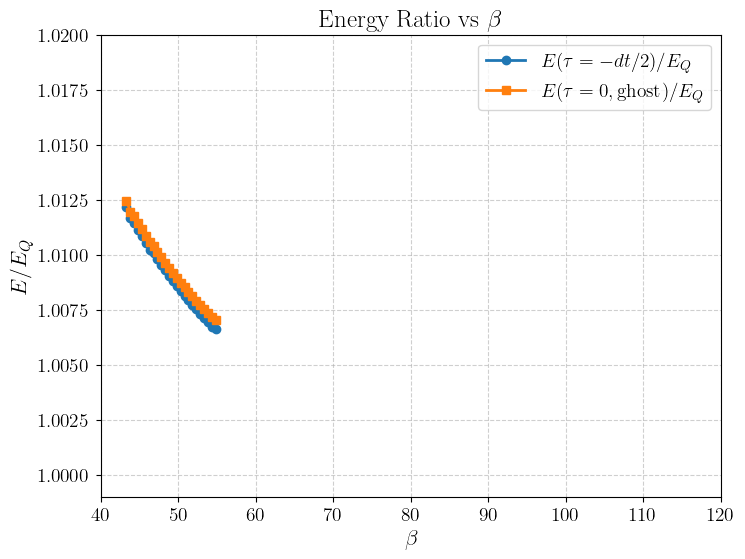

In [21]:
# --- Plot diagnostics from beta scan --- 
 
# Remove NaN values before plotting 
beta_values_plot = np.asarray(beta_values_scan) 
energy_ratios_plot = np.asarray(energy_ratios_scan) 
energy_ratios_tau0_plot = np.asarray(energy_ratios_tau0_scan) 
min_len = min(len(beta_values_plot), len(energy_ratios_plot), len(energy_ratios_tau0_plot)) 
beta_values_plot = beta_values_plot[:min_len] 
energy_ratios_plot = energy_ratios_plot[:min_len] 
energy_ratios_tau0_plot = energy_ratios_tau0_plot[:min_len] 
 
mask = ~np.isnan(energy_ratios_plot) 
mask_tau0 = ~np.isnan(energy_ratios_tau0_plot) 
beta_plot = beta_values_plot[mask] 
energy_ratios_plot_clean = energy_ratios_plot[mask] 
beta_plot_tau0 = beta_values_plot[mask_tau0] 
energy_ratios_tau0_plot_clean = energy_ratios_tau0_plot[mask_tau0] 
 
fig, ax = plt.subplots(figsize=(8, 6)) 
ax.plot(beta_plot, energy_ratios_plot_clean, marker="o", lw=2, markersize=6, label=r"$E(\tau=-dt/2)/E_Q$") 
ax.plot(beta_plot_tau0, energy_ratios_tau0_plot_clean, marker="s", lw=2, markersize=6, label=r"$E(\tau=0, \text{ghost})/E_Q$") 
ax.set_xlabel(r"$\beta$") 
ax.set_ylabel(r"$E/E_Q$") 
ax.set_ylim(0.999, 1.02)
ax.set_xlim(40, 120)
ax.set_title(r"Energy Ratio vs $\beta$") 
ax.grid(True, ls="--", alpha=0.6) 
ax.legend()
 
plt.show() 

Plot saved to: /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Q_ball_finder/notebooks/slices_solutions.pdf


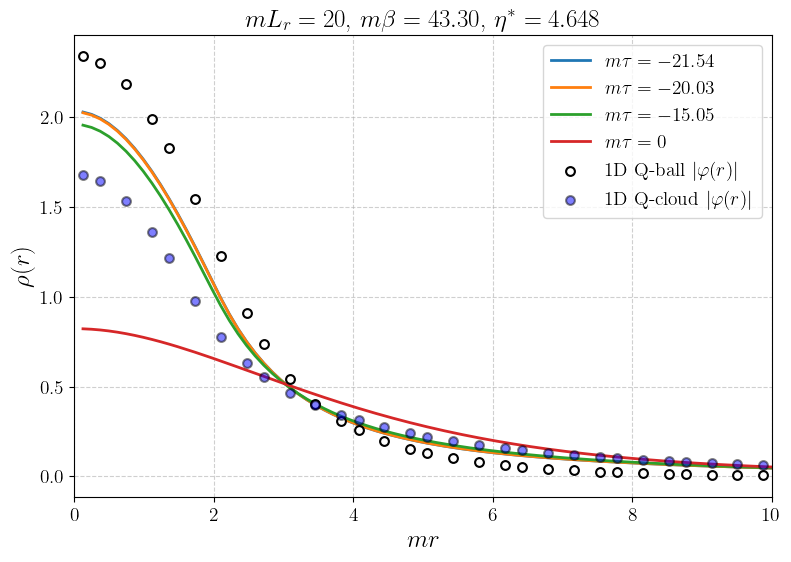

In [22]:
# --- Plot: Q-ball, Q-cloud, and 2D solution slice at tau_min for saved solution --- 
from Q_ball_finder.diagnostics import compute_energy_tau0_ghost

solution_plot_last = solutions_scan[-1].solution 
grid_plot_last = solution_plot_last.grid 
r_slice_last = grid_plot_last.r
tau_grid = grid_plot_last.tau

# Find tau with minimum index (tau_min) 
tau_idx_min_last = int(np.argmin(tau_grid)) 
tau_min_last = tau_grid[tau_idx_min_last] 

# Find indices closest to tau=-20, -15
tau_targets = [-20.0, -15.0]
tau_indices = {}
tau_values = {}
for tau_target in tau_targets:
    idx = int(np.argmin(np.abs(tau_grid - tau_target)))
    tau_indices[tau_target] = idx
    tau_values[tau_target] = tau_grid[idx]

# Extract slices from 2D solution
def extract_rho_slice(phi_slice, phibar_slice):
    return np.sqrt(np.maximum((phi_slice * phibar_slice).real, 0.0))

rho_slice_tau_min = extract_rho_slice(
    solution_plot_last.phi[:, tau_idx_min_last],
    solution_plot_last.phibar[:, tau_idx_min_last]
)

rho_slice_tau_m20 = extract_rho_slice(
    solution_plot_last.phi[:, tau_indices[-20.0]],
    solution_plot_last.phibar[:, tau_indices[-20.0]]
)

rho_slice_tau_m15 = extract_rho_slice(
    solution_plot_last.phi[:, tau_indices[-15.0]],
    solution_plot_last.phibar[:, tau_indices[-15.0]]
)

# Reconstruct rho at tau=0 using ghost reconstruction
y_tau0 = 0.5 * (solution_plot_last.ybar[:, 0] + solution_plot_last.y[:, 0])
ybar_tau0 = 0.5 * (solution_plot_last.y[:, 0] + solution_plot_last.ybar[:, 0])
phi_tau0 = y_tau0 / r_slice_last
phibar_tau0 = ybar_tau0 / r_slice_last
rho_slice_tau0 = extract_rho_slice(phi_tau0, phibar_tau0)

# Interpolate 1D profiles onto the same r grid 
rho_qball_interp_last = np.interp(r_slice_last, qball_profile.r, qball_profile.phi_abs) 
rho_qcloud_interp_last = np.interp(r_slice_last, qcloud_profile.r, qcloud_profile.phi_abs) 
 
# Plot 
fig, ax = plt.subplots(figsize=(9, 6)) 

# 2D slices: solid lines
ax.plot(r_slice_last, rho_slice_tau_min, lw=2.0, linestyle="-", label=rf"$m\tau = {tau_min_last:.2f}$") 
ax.plot(r_slice_last, rho_slice_tau_m20, lw=2.0, linestyle="-", label=rf"$m\tau = {tau_values[-20.0]:.2f}$") 
ax.plot(r_slice_last, rho_slice_tau_m15, lw=2.0, linestyle="-", label=rf"$m\tau = {tau_values[-15.0]:.2f}$") 
ax.plot(r_slice_last, rho_slice_tau0, lw=2.0, linestyle="-", label=r"$m\tau = 0$") 

# 1D profiles: scatter plot with equally spaced points
# Select equally spaced indices
n_points = 60  # Number of points to show
indices = np.linspace(0, len(r_slice_last)-1, n_points, dtype=int)
ax.scatter(r_slice_last[indices], rho_qball_interp_last[indices], 
          marker="o", s=40, facecolors='white', edgecolors='black', linewidths=1.5,
          label=rf"1D Q-ball $|\varphi(r)|$", zorder=5)
ax.scatter(r_slice_last[indices], rho_qcloud_interp_last[indices], 
          marker="o", s=40, facecolors='blue', alpha=0.5, edgecolors='black', linewidths=1.5,
          label=rf"1D Q-cloud $|\varphi(r)|$", zorder=5) 
ax.set_xlabel(r"$mr$", fontsize=18) 
ax.set_ylabel(r"$\rho(r)$", fontsize=18) 
ax.set_xlim(0, min(10, np.max(r_slice_last))) 
ax.set_title(rf"$mL_r=20$, $m\beta = {solution_plot_last.settings.beta:.2f}$, $\eta^* = {solution_plot_last.settings.eta0:.3f}$") 
ax.grid(True, ls="--", alpha=0.6) 
ax.legend() 

# Save to PDF
pdf_path = PROJECT_ROOT / "Q_ball_finder" / "notebooks" / "slices_solutions.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
print(f"Plot saved to: {pdf_path}")

plt.show() 

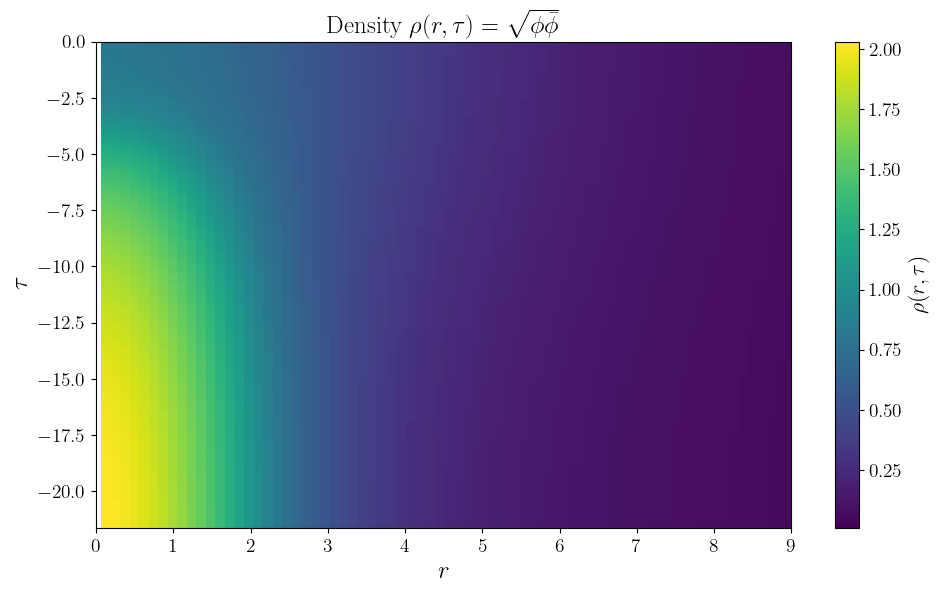

In [23]:
# Plot the solution: density rho = sqrt((phi * phibar).real) 
import matplotlib.pyplot as plt 
 
solution_plot = solution_plot_last 
grid_plot = solution_plot.grid 
 
# Compute rho from phi and phibar 
rho_2d = np.sqrt( 
 np.maximum( 
 (solution_plot.phi * solution_plot.phibar).real, 
 0.0, 
) 
) 
 
# Create meshgrid for plotting 
R_plot, T_plot = np.meshgrid(grid_plot.r, grid_plot.tau, indexing="xy") 
 
# Plot 2D density 
fig, ax = plt.subplots(figsize=(10, 10/1.618)) 
cf = ax.pcolormesh(R_plot, T_plot, rho_2d.T, shading="auto", cmap="viridis") 
ax.set_xlabel(r"$r$", fontsize=18) 
ax.set_ylabel(r"$\tau$", fontsize=18)
ax.set_xlim(0, 9)
ax.set_title(r"Density $\rho(r, \tau) = \sqrt{\phi \bar{\phi}}$") 
fig.colorbar(cf, ax=ax, label=r"$\rho(r, \tau)$") 
plt.tight_layout() 
plt.show() 

# Q-cloud solution for $Q=352.928470$

In [ ]:
delta_beta = 0.2 
beta_ref_natural = (2.0 * np.pi) / unstable_mode.gamma - delta_beta 
beta_ref = beta_ref_natural - delta_beta# manual override used in the reference runs or 
 
Nr_ref = 48 * 2 
Ntau_ref = 81 * 2 
Lr_ref = 15.0 
 
# --- Negative-mode ansatz built directly in (y, ybar) and packed for the solver --- 
grid_ref = build_grid(Nr=Nr_ref, Ntau=Ntau_ref, Lr=Lr_ref, beta=beta_ref) 
neg_mode_ansatz = build_negative_mode_ansatz( 
 profile=qcloud_profile, 
 mode=unstable_mode, 
 grid=grid_ref, 
 omega_reference=omega_cloud, 
 amplitude=1,#4,#1 
 cosh_scale=1,#3,#1 
 envelope_width=None, 
 flip_sign=True, 
 center_at_cloud=True, 
 decrease_towards_zero=True, 
) 
x0_neg_mode = pack_fields(neg_mode_ansatz.y, neg_mode_ansatz.ybar) 
 
settings_ref = QBall2DSettings( 
 beta=beta_ref, 
 ansatz_amplitude=1.5, # kept for completeness, not used when x0 provided 
 energy_reference=E_Q, 
 omega_tilde=omega_cloud, 
 Nr=Nr_ref, 
 Ntau=Ntau_ref, 
 Lr=Lr_ref, 
 newton_verbose=True, 
 ansatz_center_at_cloud=True, 
 ansatz_decrease_towards_zero=True, 
) 
 
eta_start_ref = beta_ref * (omega_cloud - omega_qball)
 
solution_beta_eta, charge_beta_eta, x0_beta_eta = solve_fixed_beta_eta( 
 params, 
 omega_qball, 
 qcloud_profile, 
 unstable_mode, 
 settings=settings_ref, 
 eta=eta_start_ref, 
 x0_initial=x0_neg_mode, 
 verbose=True, 
) 
 
print(f"Fixed β = {beta_ref:.6f}, η = {eta_start_ref:.6f}") 
print(f"Charge = {charge_beta_eta:.6f} (ratio {charge_beta_eta / g2Q_target:.6f})") 
if solution_beta_eta.energy is not None: 
    print(f"Energy (τ≈0) = {solution_beta_eta.energy:.6f}") 
if solution_beta_eta.energy_ratio is not None: 
    print(f"Energy ratio = {solution_beta_eta.energy_ratio:.6f}") 
 
x0_beta_eta = pack_fields(solution_beta_eta.y, solution_beta_eta.ybar) 
# --- Resample solution onto grid with Lr=20 and use as initial ansatz --- 
from Q_ball_finder.ansatz import AnsatzResult 
from Q_ball_finder.notebook_utils import resample_ansatz 
 
# Create AnsatzResult from the solution with Lr=15 
ansatz_Lr15 = AnsatzResult( 
 phi=solution_beta_eta.phi, 
 phibar=solution_beta_eta.phibar, 
 y=solution_beta_eta.y, 
 ybar=solution_beta_eta.ybar, 
) 
 
# Build new grid with Lr=20 (keeping Nr and Ntau the same) 
Lr_new = 20.0 
grid_Lr20 = build_grid( 
 Nr=Nr_ref, 
 Ntau=Ntau_ref, 
 Lr=Lr_new, 
 beta=beta_ref, 
) 
 
# Resample the solution onto the new grid 
ansatz_Lr20 = resample_ansatz(ansatz_Lr15, solution_beta_eta.grid, grid_Lr20, omega=omega_qball) 
x0_Lr20 = pack_fields(ansatz_Lr20.y, ansatz_Lr20.ybar) 
 
# Create new settings with Lr=20 
settings_Lr20 = QBall2DSettings( 
 beta=beta_ref, 
 ansatz_amplitude=2.5, # kept for completeness, not used when x0 provided 
 energy_reference=E_Q, 
 omega_tilde=omega_cloud, 
 Nr=Nr_ref, 
 Ntau=Ntau_ref, 
 Lr=Lr_new, 
 newton_verbose=True, 
 ansatz_center_at_cloud=True, 
 ansatz_decrease_towards_zero=True, 
) 
 
# Solve with the resampled solution as initial ansatz 
solution_Lr20, charge_Lr20, x0_Lr20_final = solve_fixed_beta_eta( 
 params, 
 omega_qball, 
 qcloud_profile, 
 unstable_mode, 
 settings=settings_Lr20, 
 eta=eta_start_ref, 
 x0_initial=x0_Lr20, 
 verbose=True, 
) 
 
print(f"\n--- Solution with Lr=20 ---") 
print(f"Fixed β = {beta_ref:.6f}, η = {eta_start_ref:.6f}") 
print(f"Charge = {charge_Lr20:.6f} (ratio {charge_Lr20 / g2Q_target:.6f})") 
 
# Energy from at slice i=0 
if solution_Lr20.energy is not None: 
    print(f"Energy ( τ≈0) = {solution_Lr20.energy:.6f}") 
if solution_Lr20.energy_ratio is not None: 
    print(f"Energy ratio () = {solution_Lr20.energy_ratio:.6f}") 
 

In [ ]:
# Plot the solution: density rho = sqrt((phi * phibar).real) 
import matplotlib.pyplot as plt 
 
solution_plot = solution_Lr20 
grid_plot = solution_plot.grid 
 
# Compute rho from phi and phibar 
rho_2d = np.sqrt( 
 np.maximum( 
 (solution_plot.phi * solution_plot.phibar).real, 
 0.0, 
) 
) 
 
# Create meshgrid for plotting 
R_plot, T_plot = np.meshgrid(grid_plot.r, grid_plot.tau, indexing="xy") 
 
# Plot 2D density 
fig, ax = plt.subplots(figsize=(10, 6)) 
cf = ax.pcolormesh(R_plot, T_plot, rho_2d.T, shading="auto", cmap="viridis") 
ax.set_xlabel(r"$r$") 
ax.set_ylabel(r"$\tau$") 
ax.set_xlim(0, 9)
ax.set_title(r"Density $\rho(r, \tau) = \sqrt{\phi \bar{\phi}}$ for Lr=20 solution") 
fig.colorbar(cf, ax=ax, label=r"$\rho(r, \tau)$") 
plt.tight_layout() 
plt.show() 

In [ ]:
# --- Eta scan starting from Lr=20 solution --- 
x0_Lr20_for_scan = pack_fields(solution_Lr20.y, solution_Lr20.ybar) 
 
result_Lr20_eta = scan_eta_to_match_charge( 
 params, 
 omega_qball, 
 qcloud_profile, 
 unstable_mode, 
 settings=settings_Lr20, 
 eta_start=eta_start_ref, 
 target_charge=g2Q_target, 
 d_eta=0.1, 
 max_scan_steps=30, 
 tol=1e-4, 
 verbose=True, 
 x0_initial=x0_Lr20_for_scan, 
) 
 
print(f"\n--- Eta scan result with Lr=20 ---") 
print(f"η* = {result_Lr20_eta.eta:.6f}") 
print(f"Charge () = {result_Lr20_eta.solution.charge:.6f} (target: {g2Q_target:.6f}, ratio: {result_Lr20_eta.solution.charge/g2Q_target:.6f})") 
# Energy from at slice i=0 
if result_Lr20_eta.solution.energy is not None: 
    print(f"Energy ( τ≈0) = {result_Lr20_eta.solution.energy:.6f}") 
if result_Lr20_eta.solution.energy_ratio is not None: 
    print(f"Energy ratio () = {result_Lr20_eta.solution.energy_ratio:.6f}")

## Scan for $\beta \to 0$

In [ ]:
# --- Beta scan with dtau-fixed grids and proper warm starts --- 

# Reference values for dtau calculation 
beta_ref_scan = beta_ref # Use the same beta_ref from above 
ntau_ref_scan = 48 * 2 #300 # Use fixed Ntau=300 for beta scan
nr_ref_scan = 81 * 2 #150 # Use fixed Nr=150 for beta scan
lr_ref_scan = 20.0 # Paper default Lr=20.0 (can override with Lr_ref if needed) 

# Beta scan parameters - use small steps for continuation 
beta_step = 0.5 # Small step for continuation (0.2-0.5 recommended) 
num_steps = 30 # Number of steps 
beta_start = beta_ref 
beta_values_scan = beta_start - beta_step * np.arange(num_steps + 1) 

# Choose whether to adjust Ntau to keep dtau constant or keep Ntau constant
adjust_ntau_for_constant_dtau = True  # Set to False to keep Ntau constant

# Storage 
eta_values_scan = [] 
energy_ratios_scan = [] 
energy_values = [] 
energy_tau0_values = []  # Energy at tau=0 (ghost reconstruction)
energy_ratios_tau0_scan = []  # Energy ratio at tau=0
solutions_scan = [] 
ntau_values = [] 
dtau_values = [] 
charge_values = [] 

# Start from the Lr=20 eta scan result 
solution_original = result_Lr20_eta.solution 
eta_current = result_Lr20_eta.eta 

# Resample the initial solution onto the new grid (Nr=150, Ntau=300)
# This ensures the first step uses the resampled solution as ansatz
from Q_ball_finder.ansatz import AnsatzResult
from Q_ball_finder.bounce2d import QBall2DSolution
from Q_ball_finder.diagnostics import compute_energy_tau0_ghost

grid_ref_scan = build_grid(nr_ref_scan, ntau_ref_scan, lr_ref_scan, beta_ref_scan)
ansatz_resampled = resample_ansatz(
    AnsatzResult(
        phi=solution_original.phi,
        phibar=solution_original.phibar,
        y=solution_original.y,
        ybar=solution_original.ybar,
    ),
    solution_original.grid,
    grid_ref_scan,
    omega=omega_qball,
    resample_phi_directly=False,
    clamp_tau_to_plateau=True,
)

# Create new solution object with resampled fields
# Use original solution's profile, unstable_mode, ansatz, and newton as placeholders
# (they won't be used in warm_start_from_solution, only y/ybar/phi/phibar/grid are needed)
solution_current = QBall2DSolution(
    y=ansatz_resampled.y,
    ybar=ansatz_resampled.ybar,
    phi=ansatz_resampled.phi,
    phibar=ansatz_resampled.phibar,
    grid=grid_ref_scan,
    settings=solution_original.settings,
    profile=solution_original.profile,
    unstable_mode=solution_original.unstable_mode,
    ansatz=solution_original.ansatz,
    newton=solution_original.newton,
)

for idx, beta_i in enumerate(beta_values_scan): 
    print(f"\n{'='*60}")
    print(f"Beta scan step {idx+1}/{len(beta_values_scan)}: β = {beta_i:.4f}")
    print(f"{'='*60}")

    # Compute Ntau: either adjust to keep dtau constant, or keep constant
    if adjust_ntau_for_constant_dtau:
        # Adjust Ntau for this beta to keep dtau approximately constant
        ntau_i = compute_ntau_for_beta(beta_i, beta_ref_scan, ntau_ref_scan, min_ntau=100)
        dtau_i = beta_i / (2.0 * ntau_i)
        print(f"Strategy: Adjusting Ntau to keep dtau constant")
    else:
        # Keep Ntau constant (use reference value)
        ntau_i = ntau_ref_scan
        dtau_i = beta_i / (2.0 * ntau_i)
        print(f"Strategy: Keeping Ntau constant")

    print(f"Ntau = {ntau_i}, dtau = {dtau_i:.6f}")

    # Build grid for this beta
    grid_i = build_grid(nr_ref_scan, ntau_i, lr_ref_scan, beta_i)
 
    # Prepare warm start: ALWAYS resample to handle grid differences (e.g., Lr changes)
    # Uses proper resampling with tau clamping and plateau enforcement
    x0_current = warm_start_from_solution(
    solution_current,
    grid_i,
    omega_qball, # Required for reconstructing phi/phibar from y/ybar
    enforce_plateau=True,
    ) 
 
    # Settings for this beta
    settings_i = QBall2DSettings(
    beta=beta_i,
    ansatz_amplitude=0.8,
    energy_reference=E_Q,
    omega_tilde=omega_cloud,
    Nr=nr_ref_scan,
    Ntau=ntau_i,
    Lr=lr_ref_scan,
    newton_verbose=True,
    ) 
 
    # Use eta* from previous step as starting point
    eta_start_i = eta_current
 
    # Run eta scan
    result_i = scan_eta_to_match_charge(
    params,
    omega_qball,
    qcloud_profile,
    unstable_mode,
    settings=settings_i,
    eta_start=eta_start_i,
    target_charge=g2Q_target,
    d_eta=0.05,
    max_scan_steps=30,
    tol=1e-4,
    verbose=True,
    x0_initial=x0_current,
    )
    # Store results 
    eta_values_scan.append(result_i.eta)
    solutions_scan.append(result_i)
    ntau_values.append(ntau_i)
    dtau_values.append(dtau_i)
    charge_values.append(result_i.solution.charge)
    
    # Store energy results (at slice i=0)
    if result_i.solution.energy is not None:
        energy_values.append(result_i.solution.energy)
        energy_ratios_scan.append(result_i.solution.energy_ratio)
    else:
        energy_values.append(None)
        energy_ratios_scan.append(None)
    
    # Compute and store energy at tau=0 (ghost reconstruction)
    try:
        E_tau0 = compute_energy_tau0_ghost(
            result_i.solution.y,
            result_i.solution.ybar,
            result_i.solution.grid,
            omega_qball,
            result_i.solution.settings.eta0,
            params,
        )
        energy_tau0_values.append(E_tau0)
        energy_ratios_tau0_scan.append(E_tau0 / E_Q)
    except Exception as e:
        print(f"Warning: Failed to compute energy at tau=0: {e}")
        energy_tau0_values.append(None)
        energy_ratios_tau0_scan.append(None)
    
    # Print diagnostics
    print(f"\n--- Diagnostics for β = {beta_i:.4f} ---")
    print(f"η* = {result_i.eta:.6f}")
    print(f"Q = {result_i.solution.charge:.6f} (target: {g2Q_target:.6f}, ratio: {result_i.solution.charge/g2Q_target:.6f})")
    print(f"Ntau = {ntau_i}, dtau = {dtau_i:.6f}")
    # Print energy (at slice i=0)
    if result_i.solution.energy is not None:
        print(f"Energy (τ≈0) = {result_i.solution.energy:.6f}")
        if result_i.solution.energy_ratio is not None:
            print(f"Energy ratio = {result_i.solution.energy_ratio:.6f}")
    # Print energy at tau=0 (ghost reconstruction)
    if energy_tau0_values[-1] is not None:
        print(f"Energy (τ=0, ghost) = {energy_tau0_values[-1]:.6f}")
        if energy_ratios_tau0_scan[-1] is not None:
            print(f"Energy ratio (τ=0, ghost) = {energy_ratios_tau0_scan[-1]:.6f}")
    
    # Update for next iteration: use eta* from current step as initial eta for next step
    # Save final solution after this step
    solution_save_dir = PROJECT_ROOT / "Q_ball_finder" / "data" / "beta_scan_solutions"
    solution_save_dir.mkdir(parents=True, exist_ok=True)
    solution_save_path = solution_save_dir / f"solution_beta_{beta_i:.4f}.npz"
    np.savez(
        solution_save_path,
        r=result_i.solution.grid.r,
        tau=result_i.solution.grid.tau,
        y=result_i.solution.y,
        ybar=result_i.solution.ybar,
        phi=result_i.solution.phi,
        phibar=result_i.solution.phibar,
        beta=result_i.solution.settings.beta,
        eta=result_i.eta,
        charge=result_i.solution.charge,
        energy=result_i.solution.energy,
        energy_ratio=result_i.solution.energy_ratio,
    )

    solution_current = result_i.solution
    eta_current = result_i.eta  # This will be used as eta_start_i in the next iteration

# Convert to arrays 
eta_values_scan = np.array(eta_values_scan) 


In [ ]:
# --- Plot diagnostics from beta scan --- 
 
# Remove NaN values before plotting 
beta_values_plot = np.asarray(beta_values_scan) 
energy_ratios_plot = np.asarray(energy_ratios_scan) 
energy_ratios_tau0_plot = np.asarray(energy_ratios_tau0_scan) 
min_len = min(len(beta_values_plot), len(energy_ratios_plot), len(energy_ratios_tau0_plot)) 
beta_values_plot = beta_values_plot[:min_len] 
energy_ratios_plot = energy_ratios_plot[:min_len] 
energy_ratios_tau0_plot = energy_ratios_tau0_plot[:min_len] 
 
mask = ~np.isnan(energy_ratios_plot) 
mask_tau0 = ~np.isnan(energy_ratios_tau0_plot) 
beta_plot = beta_values_plot[mask] 
energy_ratios_plot_clean = energy_ratios_plot[mask] 
beta_plot_tau0 = beta_values_plot[mask_tau0] 
energy_ratios_tau0_plot_clean = energy_ratios_tau0_plot[mask_tau0] 
 
fig, ax = plt.subplots(figsize=(8, 6)) 
ax.plot(beta_plot, energy_ratios_plot_clean, marker="o", lw=2, markersize=6, label=r"$E(\tau=-dt/2)/E_Q$") 
ax.plot(beta_plot_tau0, energy_ratios_tau0_plot_clean, marker="s", lw=2, markersize=6, label=r"$E(\tau=0, \text{ghost})/E_Q$") 
ax.set_xlabel(r"$\beta$") 
ax.set_ylabel(r"$E/E_Q$") 
ax.set_ylim(0.999, 1.02)
ax.set_xlim(40, 120)
ax.set_title(r"Energy Ratio vs $\beta$") 
ax.grid(True, ls="--", alpha=0.6) 
ax.legend()
 
plt.show() 

In [ ]:
# --- Plot: Q-ball, Q-cloud, and 2D solution slice at tau_min for saved solution --- 
from Q_ball_finder.diagnostics import compute_energy_tau0_ghost

solution_plot_last = solutions_scan[-1].solution 
grid_plot_last = solution_plot_last.grid 
r_slice_last = grid_plot_last.r
tau_grid = grid_plot_last.tau

# Find tau with minimum index (tau_min) 
tau_idx_min_last = int(np.argmin(tau_grid)) 
tau_min_last = tau_grid[tau_idx_min_last] 

# Find indices closest to tau=-20, -15
tau_targets = [-20.0, -15.0]
tau_indices = {}
tau_values = {}
for tau_target in tau_targets:
    idx = int(np.argmin(np.abs(tau_grid - tau_target)))
    tau_indices[tau_target] = idx
    tau_values[tau_target] = tau_grid[idx]

# Extract slices from 2D solution
def extract_rho_slice(phi_slice, phibar_slice):
    return np.sqrt(np.maximum((phi_slice * phibar_slice).real, 0.0))

rho_slice_tau_min = extract_rho_slice(
    solution_plot_last.phi[:, tau_idx_min_last],
    solution_plot_last.phibar[:, tau_idx_min_last]
)

rho_slice_tau_m20 = extract_rho_slice(
    solution_plot_last.phi[:, tau_indices[-20.0]],
    solution_plot_last.phibar[:, tau_indices[-20.0]]
)

rho_slice_tau_m15 = extract_rho_slice(
    solution_plot_last.phi[:, tau_indices[-15.0]],
    solution_plot_last.phibar[:, tau_indices[-15.0]]
)

# Reconstruct rho at tau=0 using ghost reconstruction
y_tau0 = 0.5 * (solution_plot_last.ybar[:, 0] + solution_plot_last.y[:, 0])
ybar_tau0 = 0.5 * (solution_plot_last.y[:, 0] + solution_plot_last.ybar[:, 0])
phi_tau0 = y_tau0 / r_slice_last
phibar_tau0 = ybar_tau0 / r_slice_last
rho_slice_tau0 = extract_rho_slice(phi_tau0, phibar_tau0)

# Interpolate 1D profiles onto the same r grid 
rho_qball_interp_last = np.interp(r_slice_last, qball_profile.r, qball_profile.phi_abs) 
rho_qcloud_interp_last = np.interp(r_slice_last, qcloud_profile.r, qcloud_profile.phi_abs) 
 
# Plot 
fig, ax = plt.subplots(figsize=(9, 6)) 

# 2D slices: solid lines
ax.plot(r_slice_last, rho_slice_tau_min, lw=2.0, linestyle="-", label=rf"$m\tau = {tau_min_last:.2f}$") 
ax.plot(r_slice_last, rho_slice_tau_m20, lw=2.0, linestyle="-", label=rf"$m\tau = {tau_values[-20.0]:.2f}$") 
ax.plot(r_slice_last, rho_slice_tau_m15, lw=2.0, linestyle="-", label=rf"$m\tau = {tau_values[-15.0]:.2f}$") 
ax.plot(r_slice_last, rho_slice_tau0, lw=2.0, linestyle="-", label=r"$m\tau = 0$") 

# 1D profiles: scatter plot with equally spaced points
# Select equally spaced indices
n_points = 60  # Number of points to show
indices = np.linspace(0, len(r_slice_last)-1, n_points, dtype=int)
ax.scatter(r_slice_last[indices], rho_qball_interp_last[indices], 
          marker="o", s=40, facecolors='white', edgecolors='black', linewidths=1.5,
          label=rf"1D Q-ball $|\varphi(r)|$", zorder=5)
ax.scatter(r_slice_last[indices], rho_qcloud_interp_last[indices], 
          marker="o", s=40, facecolors='blue', alpha=0.5, edgecolors='black', linewidths=1.5,
          label=rf"1D Q-cloud $|\varphi(r)|$", zorder=5) 
ax.set_xlabel(r"$mr$", fontsize=18) 
ax.set_ylabel(r"$\rho(r)$", fontsize=18) 
ax.set_xlim(0, min(10, np.max(r_slice_last))) 
ax.set_title(rf"$mL_r=20$, $m\beta = {solution_plot_last.settings.beta:.2f}$, $\eta^* = {solution_plot_last.settings.eta0:.3f}$") 
ax.grid(True, ls="--", alpha=0.6) 
ax.legend() 

# Save to PDF
pdf_path = PROJECT_ROOT / "Q_ball_finder" / "notebooks" / "slices_solutions.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
print(f"Plot saved to: {pdf_path}")

plt.show() 

In [ ]:
# Plot the solution: density rho = sqrt((phi * phibar).real) 
import matplotlib.pyplot as plt 
 
solution_plot = solution_plot_last 
grid_plot = solution_plot.grid 
 
# Compute rho from phi and phibar 
rho_2d = np.sqrt( 
 np.maximum( 
 (solution_plot.phi * solution_plot.phibar).real, 
 0.0, 
) 
) 
 
# Create meshgrid for plotting 
R_plot, T_plot = np.meshgrid(grid_plot.r, grid_plot.tau, indexing="xy") 
 
# Plot 2D density 
fig, ax = plt.subplots(figsize=(10, 10/1.618)) 
cf = ax.pcolormesh(R_plot, T_plot, rho_2d.T, shading="auto", cmap="viridis") 
ax.set_xlabel(r"$r$", fontsize=18) 
ax.set_ylabel(r"$\tau$", fontsize=18)
ax.set_xlim(0, 9)
ax.set_title(r"Density $\rho(r, \tau) = \sqrt{\phi \bar{\phi}}$") 
fig.colorbar(cf, ax=ax, label=r"$\rho(r, \tau)$") 
plt.tight_layout() 
plt.show() 

# Final Plot with Q-cloud and Q-ball branch

In [148]:
# Extract and save data from previous runs
# Q-ball branch - 1
beta_qball1 = np.array([54.8, 59.8, 64.8, 69.8, 74.8, 79.8, 84.8, 89.8, 94.8, 99.8, 104.8, 109.8, 114.8, 119.8, 124.8, 129.8, 134.8, 139.8, 144.8])
#energy_ratio_qball1_std = np.array([1.00658473, 1.00488594, 1.00347117, 1.00230676, 1.00141157, 1.00075762, 1.00029408, 1.00001411, 0.99984805, 0.99975706, 0.99970555, 0.99968725, 0.99966932, 0.9996609, 0.99966097, 0.99966018, 0.99966067, 0.99966371, 0.99964332])
#energy_ratio_qball1_tau0 = np.array([1.00701504, 1.00532975, 1.00391173, 1.00274505, 1.00183549, 1.0011821, 1.0007087, 1.0004313, 1.00026816, 1.00017065, 1.0001225, 1.0001074, 1.00008419, 1.00007887, 1.00007424, 1.00007639, 1.00007963, 1.00007844, 1.00006067])
energy_ratio_qball1_std = np.array([1.00667712, 1.00488594, 1.00347117, 1.00230676, 1.00141157, 1.00075762, 1.00029408, 1.00001411, 0.99984805, 0.99975706, 0.99970555, 0.99968725, 0.99966932, 0.9996609, 0.99966097, 0.99966018, 0.99966067, 0.99966371, 0.99964332])
energy_ratio_qball1_tau0 = np.array([1.00714467, 1.00532975, 1.00391173, 1.00274505, 1.00183549, 1.0011821, 1.0007087, 1.0004313, 1.00026816, 1.00017065, 1.0001225, 1.0001074, 1.00008419, 1.00007887, 1.00007424, 1.00007639, 1.00007963, 1.00007844, 1.00006067])

# Q-ball branch - 2
beta_qball2 = np.array([54.8, 54.3, 53.8, 53.3, 52.8, 52.3, 51.8, 51.3, 50.8, 50.3, 49.8, 49.3, 48.8, 48.3,
 47.8, 47.3, 46.8, 46.3, 45.8, 45.3, 44.8, 44.3, 43.8, 43.3, 42.8, 41.8])
energy_ratio_qball2_std = np.array([1.00667712, 1.00686546, 1.00705557, 1.00724906, 1.00744604, 1.00764659,
 1.00785084, 1.00805889, 1.00827089, 1.00848701, 1.00870743, 1.00893237,
 1.00916209, 1.0093969, 1.00963718, 1.00988342, 1.01013626, 1.01039661,
 1.01066582, 1.01094618, 1.01124217, 1.01156425, 1.0119439, 1.01219884,
 1.01257495, 1.01434439])
energy_ratio_qball2_tau0 = np.array([1.00714467, 1.0073259, 1.00750897, 1.00769548, 1.00788552, 1.0080792,
 1.00827663, 1.00847793, 1.00868324, 1.00889272, 1.00910657, 1.00932499,
 1.00954826, 1.00977668, 1.01001065, 1.01025063, 1.0104973, 1.01075154,
 1.01101473, 1.01128917, 1.01157934, 1.01189571, 1.0122698, 1.01251941,
 1.01289048, 1.01465939])

# Q-cloud branch - 1
beta_qcloud1 = np.array([48.41206706, 47.41206706, 46.41206706, 45.41206706, 44.41206706, 43.41206706, 42.41206706])
energy_ratio_qcloud1_std = np.array([1.01697862, 1.0165593, 1.01615575, 1.01577701, 1.01542585, 1.01507836, 1.01474064])
energy_ratio_qcloud1_tau0 = np.array([1.01704439, 1.01658467, 1.01617808, 1.01579689, 1.0154437, 1.01509449, 1.01475518])

# Compute beta_natural
beta_natural = 2.0 * np.pi / unstable_mode.gamma

print(f"Data loaded:")
print(f"  Q-ball branch - 1: {len(beta_qball1)} points")
print(f"  Q-ball branch - 2: {len(beta_qball2)} points")
print(f"  Q-cloud branch - 1: {len(beta_qcloud1)} points")
print(f"  Beta natural = {beta_natural:.6f}")

Data loaded:
  Q-ball branch - 1: 19 points
  Q-ball branch - 2: 26 points
  Q-cloud branch - 1: 7 points
  Beta natural = 48.812067


Plot saved to: /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Q_ball_finder/notebooks/energy_ratio_vs_beta.pdf


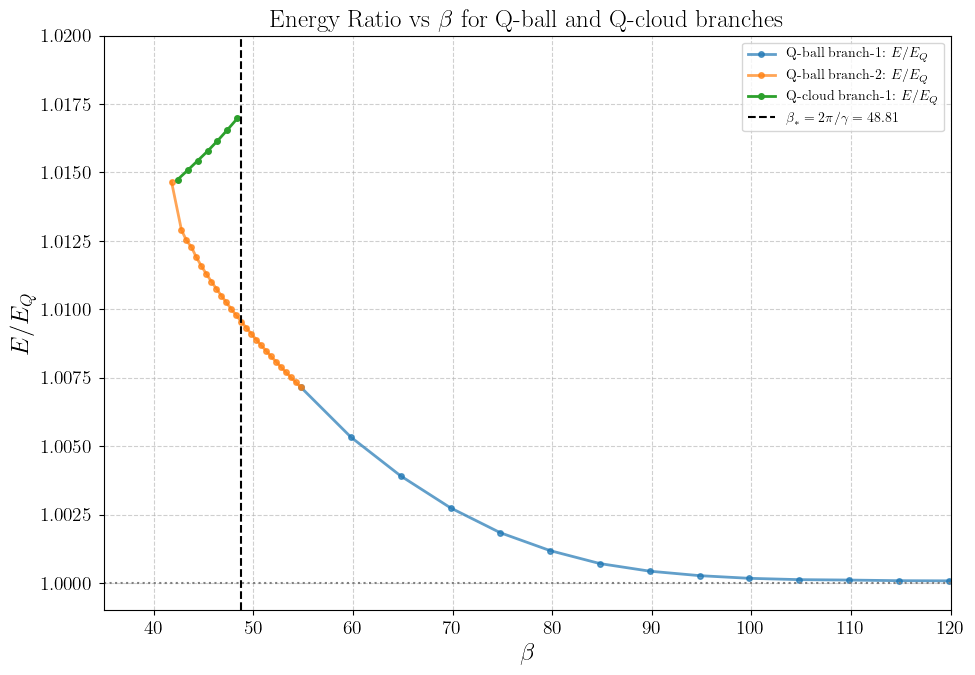

In [149]:
# Plot E/E_Q vs beta for all three branches
fig, ax = plt.subplots(figsize=(10, 7))

# Plot Q-ball branch - 1 (tau=-dt/2)
#ax.plot(beta_qball1, energy_ratio_qball1_std, marker="o", lw=2, markersize=6, linestyle="--",
#        label=r"Q-ball branch-1: $E(\tau=-dt/2)/E_Q$", color="C0")
# Plot Q-ball branch - 1 (tau=0)
ax.plot(beta_qball1, energy_ratio_qball1_tau0, marker="o", lw=2, markersize=4, 
        label=r"Q-ball branch-1: $E/E_Q$", color="C0", linestyle="-", alpha=0.7)

# Plot Q-ball branch - 2 (tau=-dt/2)
#ax.plot(beta_qball2, energy_ratio_qball2_std, marker="o", lw=2, markersize=6, linestyle="--",
#        label=r"Q-ball branch-2: $E(\tau=-dt/2)/E_Q$", color="C1")
# Plot Q-ball branch - 2 (tau=0)
ax.plot(beta_qball2, energy_ratio_qball2_tau0, marker="o", lw=2, markersize=4, 
        label=r"Q-ball branch-2: $E/E_Q$", color="C1", linestyle="-", alpha=0.7)

# Plot Q-cloud branch - 1 (tau=-dt/2)
ax.plot(beta_qcloud1, energy_ratio_qcloud1_std, marker="o", lw=2, markersize=4, 
        label=r"Q-cloud branch-1: $E/E_Q$", color="C2")
# Plot Q-cloud branch - 1 (tau=0)
#ax.plot(beta_qcloud1, energy_ratio_qcloud1_tau0, marker="s", lw=2, markersize=5, 
#        label=r"Q-cloud branch-1: $E(\tau=0, \text{ghost})/E_Q$", color="C2", linestyle="--", alpha=0.7)

# Add vertical line at beta_natural
ax.axvline(beta_natural, color="black", linestyle="--", lw=1.5, label=rf"$\beta_{{*}} = 2\pi/\gamma = {beta_natural:.2f}$")

# Add horizontal line at E/E_Q = 1
ax.axhline(1.0, color="gray", linestyle=":", lw=1.5)#, label=r"$E/E_Q = 1$")

ax.set_xlabel(r"$\beta$", fontsize=18)
ax.set_ylabel(r"$E/E_Q$", fontsize=18)
ax.set_xlim(35, 120)
ax.set_ylim(0.999, 1.02)
ax.set_title(r"Energy Ratio vs $\beta$ for Q-ball and Q-cloud branches")
ax.grid(True, ls="--", alpha=0.6)
ax.legend(loc="best", fontsize=10, ncol=1)

plt.tight_layout()

# Save to PDF
pdf_path = PROJECT_ROOT / "Q_ball_finder" / "notebooks" / "energy_ratio_vs_beta.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
print(f"Plot saved to: {pdf_path}")

plt.show()

# Computation of the rate

## Theory

In the semiclassical approach, the decay rate $\Gamma$ of a metastable Q-ball at finite density is given by:

$$\Gamma \sim e^{-F_{Q,\beta}}$$

where $F_{Q,\beta}$ is the **suppression exponent**, which is the difference between the Euclidean action of the classical bounce solution $\phi_{\rm cl}$ and the Q-ball action, plus a chemical potential term:

$$F_{Q,\beta} = S_E[\phi_{\rm cl}] - S_E[\phi_Q] + \eta_0 Q$$

Here:
- $S_E[\phi_{\rm cl}]$ is the Euclidean action of the 2D bounce solution over the full interval $(-\beta/2, \beta/2)$
- $S_E[\phi_Q] = \beta (E_Q - \omega Q)$ is the Euclidean action of the Q-ball configuration
- $\eta_0$ is the chemical potential chosen to match the target charge $Q$
- The full action is computed using time-reflection symmetry: $S_E[\phi_{\rm cl}] = 2 \cdot S_E^{\rm half}[\phi_{\rm cl}]$, where $S_E^{\rm half}$ is computed over the half-interval $(-\beta/2, 0)$

Additionally, we compute the **activation/Q-cloud exponent**:

$$F_{\rm cloud} = \beta (E_{\rm cloud} - E_Q)$$

where $E_{\rm cloud}$ is the Q-cloud energy at the same conserved charge $Q$. The physical decay rate is then given by the minimum of these two exponents:

$$F = \min(F_{Q,\beta}, F_{\rm cloud})$$

In [10]:
# Compute suppression exponent for each solution in the beta scan

from Q_ball_finder.rate_exponent import (
    compute_suppression_exponent,
    compute_suppression_exponent_direct_difference,
    compute_activation_exponent,
    make_V_of_s_from_params,
)
from Q_ball_finder.potentials import logistic_potential_rho
from Q_ball_finder.qball_observables import compute_energy
from Q_ball_finder.bounce2d import QBall2DSolution, QBall2DSettings, EtaScanResult
from Q_ball_finder.grid import RadialTimeGrid, pack_fields
from Q_ball_finder.nr_solver import NewtonResult
from pathlib import Path
import glob

# Always load solutions from saved files (ignore any existing solutions_scan)
print("Loading solutions from saved files...")
solution_save_dir = PROJECT_ROOT / "Q_ball_finder" / "data" / "beta_scan_solutions"
solution_files = glob.glob(str(solution_save_dir / "solution_beta_*.npz"))

if len(solution_files) == 0:
    raise ValueError(f"No solution files found in {solution_save_dir}")

# Sort by beta value (extract from filename)
import re
def extract_beta(filename):
    match = re.search(r'solution_beta_([\d.]+)\.npz', filename)
    if match:
        return float(match.group(1))
    return 0.0

solution_files = sorted(solution_files, key=extract_beta)
print(f"Found {len(solution_files)} solution files, sorted by beta")

solutions_scan = []
failed_files = []
print(f"Loading {len(solution_files)} solution files...")
for idx, sol_file in enumerate(solution_files):
    try:
        if (idx + 1) % 10 == 0 or idx == 0:
            # Extract beta from filename for logging
            match = re.search(r'solution_beta_([\d.]+)\.npz', sol_file)
            beta_from_file = match.group(1) if match else 'unknown'
            print(f"  Loading {idx+1}/{len(solution_files)}: beta={beta_from_file}")
        data = np.load(sol_file)
        
        # Extract saved data
        r = data['r']
        tau = data['tau']
        y = data['y']
        ybar = data['ybar']
        phi = data['phi']
        phibar = data['phibar']
        beta = float(data['beta'])
        eta = float(data['eta'])
        charge = float(data['charge'])
        energy = float(data['energy']) if 'energy' in data else None
        energy_ratio = float(data['energy_ratio']) if 'energy_ratio' in data else None
        
        # Reconstruct grid
        Nr = len(r)
        Ntau = len(tau)
        dr = r[1] - r[0] if Nr > 1 else r[0]
        dtau = abs(tau[1] - tau[0]) if Ntau > 1 else abs(tau[0]) * 2
        Lr = r[-1]
        grid = RadialTimeGrid(r=r, tau=tau, dr=dr, dtau=dtau, Nr=Nr, Ntau=Ntau)
        
        # Reconstruct settings
        settings = QBall2DSettings(
            beta=beta,
            eta0=eta,
            energy_reference=E_Q,
            omega_tilde=omega_cloud,
            Nr=Nr,
            Ntau=Ntau,
            Lr=Lr,
        )
        
        # Create placeholder NewtonResult
        newton = NewtonResult(
            x=pack_fields(y, ybar),
            success=True,
            iterations=0,
            residual_norm=0.0,
        )
        
        # Reconstruct QBall2DSolution
        solution = QBall2DSolution(
            settings=settings,
            grid=grid,
            profile=qcloud_profile,
            unstable_mode=unstable_mode,
            ansatz=None,
            newton=newton,
            y=y,
            ybar=ybar,
            phi=phi,
            phibar=phibar,
            charge=charge,
            energy=energy,
            energy_ratio=energy_ratio,
        )
        
        # Create EtaScanResult
        result = EtaScanResult(
            eta=eta,
            charge=charge,
            solution=solution,
            history=[],
            bracket=(eta, eta),
        )
        solutions_scan.append(result)
    except Exception as e:
        failed_files.append((sol_file, str(e)))
        print(f"Warning: Failed to load {sol_file}: {e}")
        continue
    
print(f"\nLoaded {len(solutions_scan)} solutions from saved files")
if len(solutions_scan) > 0:
    beta_loaded = [sol.solution.settings.beta for sol in solutions_scan]
    print(f"Beta range loaded: {min(beta_loaded):.2f} to {max(beta_loaded):.2f}")
if failed_files:
    print(f"\nWarning: {len(failed_files)} files failed to load:")
    for fname, err in failed_files:
        print(f"  {fname}: {err}")

# Get potential function and shift so V(0)=0
V_of_s = make_V_of_s_from_params(params)

# Compute Q-cloud energy E_cloud from qcloud_profile.solution
E_cloud = compute_energy(qcloud_profile.solution, omega=omega_cloud, potential_chi=V_chi)
print(f"Q-cloud energy E_cloud = {E_cloud:.6f}")
print(f"Q-ball energy E_Q = {E_Q:.6f}")

# Optional: Sanity check - compare legacy vs direct-difference method for first solution
if len(solutions_scan) > 0:
    print("\n--- Sanity check: Comparing legacy vs direct-difference method ---")
    sol_test = solutions_scan[0].solution
    beta_test = sol_test.settings.beta
    eta_test = solutions_scan[0].eta
    
    # Legacy method
    F_legacy = compute_suppression_exponent(
        sol_test.y,
        sol_test.ybar,
        sol_test.grid,
        omega_qball,
        eta_test,
        beta_test,
        V_of_s,
        E_Q,
        g2Q_target,
    )
    
    # Direct-difference method
    F_direct = compute_suppression_exponent_direct_difference(
        sol_test.y,
        sol_test.ybar,
        sol_test.grid,
        omega_qball,
        eta_test,
        beta_test,
        V_of_s,
        qball_profile,
        g2Q_target,
    )
    
    print(f"Beta = {beta_test:.2f}:")
    print(f"  F_legacy            = {F_legacy:.8f}")
    print(f"  F_direct_difference = {F_direct:.8f}")
    print(f"  Relative difference = {abs(F_direct - F_legacy) / abs(F_legacy):.6e}")
    print("(Using direct-difference method for all solutions)\n")

# Compute suppression exponents for each solution in solutions_scan
F_tunnel_values = []
F_cloud_values = []
F_min_values = []
beta_values_exponent = []

failed_computations = []
print(f"\nComputing exponents for {len(solutions_scan)} solutions...")
for idx, result_i in enumerate(solutions_scan):
    try:
        sol = result_i.solution
        beta_i = sol.settings.beta
        eta_i = result_i.eta
        
        if (idx + 1) % 5 == 0 or idx == 0:
            print(f"  Processing {idx+1}/{len(solutions_scan)}: beta={beta_i:.2f}")
        
        # Compute F_tunnel using stable direct-difference method
        F_tunnel_i = compute_suppression_exponent_direct_difference(
            sol.y,
            sol.ybar,
            sol.grid,
            omega_qball,
            eta_i,
            beta_i,
            V_of_s,
            qball_profile,
            g2Q_target,
        )
        
        # Compute F_cloud
        F_cloud_i = compute_activation_exponent(beta_i, E_cloud, E_Q)
        
        # Minimum envelope
        F_min_i = min(F_tunnel_i, F_cloud_i)
        
        F_tunnel_values.append(F_tunnel_i)
        F_cloud_values.append(F_cloud_i)
        F_min_values.append(F_min_i)
        beta_values_exponent.append(beta_i)
    except Exception as e:
        beta_val = beta_i if 'beta_i' in locals() else 'unknown'
        failed_computations.append((beta_val, str(e)))
        print(f"  ERROR at {idx+1}/{len(solutions_scan)}: beta={beta_val}, error={e}")
        import traceback
        traceback.print_exc()
        continue

if failed_computations:
    print(f"\nWarning: {len(failed_computations)} computations failed:")
    for beta_val, err in failed_computations:
        print(f"  beta={beta_val}: {err}")

# Convert to arrays
F_tunnel_values = np.array(F_tunnel_values)
F_cloud_values = np.array(F_cloud_values)
F_min_values = np.array(F_min_values)
beta_values_exponent = np.array(beta_values_exponent)

# Extend F_cloud down to beta=35 (easy to compute: F_cloud = beta * (E_cloud - E_Q))
beta_min_loaded = beta_values_exponent.min() if len(beta_values_exponent) > 0 else 60.0
beta_min_extend = 35.0

if beta_min_loaded > beta_min_extend:
    # Create extended beta range from beta_min_extend to beta_min_loaded
    beta_extended = np.linspace(beta_min_extend, beta_min_loaded, num=50, endpoint=False)
    # Compute F_cloud for extended range
    F_cloud_extended = np.array([compute_activation_exponent(beta, E_cloud, E_Q) for beta in beta_extended])
    
    # Combine with existing values
    beta_values_exponent = np.concatenate([beta_extended, beta_values_exponent])
    F_cloud_values = np.concatenate([F_cloud_extended, F_cloud_values])
    
    # Sort by beta to keep everything ordered
    sort_idx = np.argsort(beta_values_exponent)
    beta_values_exponent = beta_values_exponent[sort_idx]
    F_cloud_values = F_cloud_values[sort_idx]
    
    # For F_tunnel and F_min, we only have values for loaded solutions
    # Pad with NaN or extend F_tunnel with NaN for extended range
    F_tunnel_extended = np.full(len(beta_extended), np.nan)
    F_tunnel_values = np.concatenate([F_tunnel_extended, F_tunnel_values])[sort_idx]
    F_min_extended = np.full(len(beta_extended), np.nan)
    F_min_values = np.concatenate([F_min_extended, F_min_values])[sort_idx]
    
    print(f"\nExtended F_cloud down to beta={beta_min_extend:.2f}")
    print(f"Extended beta range: {beta_values_exponent.min():.2f} to {beta_values_exponent.max():.2f}")

print(f"\nComputed exponents for {len(beta_values_exponent)} beta values")
print(f"Beta range: {beta_values_exponent.min():.2f} to {beta_values_exponent.max():.2f}")


Loading solutions from saved files...
Found 47 solution files, sorted by beta
Loading 47 solution files...
  Loading 1/47: beta=43.3000
  Loading 10/47: beta=47.8000
  Loading 20/47: beta=52.8000
  Loading 30/47: beta=84.8000
  Loading 40/47: beta=134.8000

Loaded 47 solutions from saved files
Beta range loaded: 43.30 to 169.80
Q-cloud energy E_cloud = 370.229909
Q-ball energy E_Q = 363.623465

--- Sanity check: Comparing legacy vs direct-difference method ---
Beta = 43.30:
  F_legacy            = 283.84766056
  F_direct_difference = 287.24400273
  Relative difference = 1.196537e-02
(Using direct-difference method for all solutions)


Computing exponents for 47 solutions...
  Processing 1/47: beta=43.30
  Processing 5/47: beta=45.30
  Processing 10/47: beta=47.80
  Processing 15/47: beta=50.30
  Processing 20/47: beta=52.80
  Processing 25/47: beta=59.80
  Processing 30/47: beta=84.80
  Processing 35/47: beta=109.80
  Processing 40/47: beta=134.80
  Processing 45/47: beta=159.80

Exten

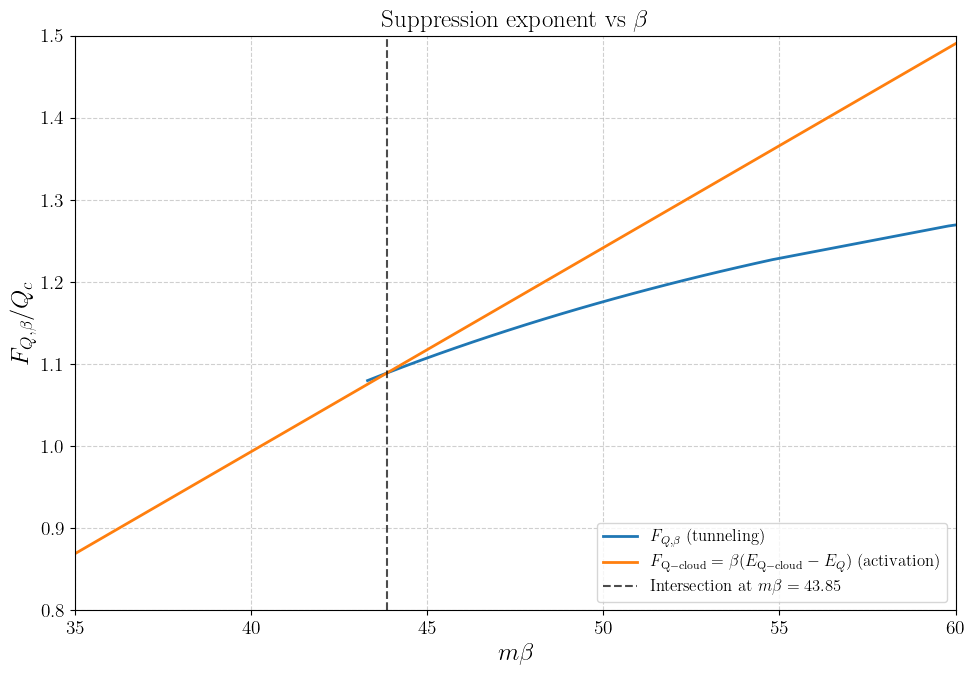

In [ ]:

# Plot suppression exponent vs beta (Fig. 7(b) style)
fig, ax = plt.subplots(figsize=(10, 7))

# Normalize beta by m to get m*beta on x-axis
m_beta_values = params.m * beta_values_exponent

# Normalize by Q_crit
# (computed in the 1D inputs cell from omega_min; fallback to legacy constant)
Q_crit = float(Q_crit) if 'Q_crit' in globals() else 266.0
F_tunnel_normalized = F_tunnel_values / Q_crit
F_cloud_normalized = F_cloud_values / Q_crit
F_min_normalized = F_min_values / Q_crit

# Plot F_tunnel (only where we have values, skip NaN)
mask_tunnel = ~np.isnan(F_tunnel_normalized)
if np.any(mask_tunnel):
    ax.plot(m_beta_values[mask_tunnel], F_tunnel_normalized[mask_tunnel], 
            lw=2, 
            label=r"$F_{Q,\beta}$ (tunneling)", color="C0")

# Plot F_cloud (extended down to beta=35)
ax.plot(m_beta_values, F_cloud_normalized, lw=2, 
        label=r"$F_{\rm Q-cloud} = \beta(E_{\rm Q-cloud} - E_Q)$ (activation)", color="C1")

# Find intersection between F_tunnel and F_cloud
# Only consider points where both are defined (not NaN)
mask_both = ~np.isnan(F_tunnel_normalized) & ~np.isnan(F_cloud_normalized)
if np.any(mask_both):
    m_beta_both = m_beta_values[mask_both]
    F_tunnel_both = F_tunnel_normalized[mask_both]
    F_cloud_both = F_cloud_normalized[mask_both]
    
    # Find where F_tunnel crosses F_cloud (difference changes sign)
    diff = F_tunnel_both - F_cloud_both
    
    # Find zero crossings
    intersection_beta = None
    for i in range(len(diff) - 1):
        if diff[i] * diff[i+1] <= 0:  # Sign change (or zero)
            # Linear interpolation to find exact intersection
            if abs(diff[i+1] - diff[i]) > 1e-10:  # Avoid division by zero
                t = -diff[i] / (diff[i+1] - diff[i])
                intersection_beta = m_beta_both[i] + t * (m_beta_both[i+1] - m_beta_both[i])
                break
    
    # If no crossing found, check if they're equal at any point
    if intersection_beta is None:
        min_diff_idx = np.argmin(np.abs(diff))
        if np.abs(diff[min_diff_idx]) < 1e-6:
            intersection_beta = m_beta_both[min_diff_idx]
    
    # Plot vertical line at intersection
    if intersection_beta is not None:
        ax.axvline(intersection_beta, color='black', linestyle='--', linewidth=1.5, 
                   alpha=0.7, label=f'Intersection at $m\\beta={intersection_beta:.2f}$')

# Plot minimum envelope (only where we have both values)
#mask_min = ~np.isnan(F_min_normalized)
#if np.any(mask_min):
#    ax.plot(m_beta_values[mask_min], F_min_normalized[mask_min], 
#            lw=2, linestyle="--", alpha=0.7, 
#            label=r"$\min(F_{Q,\beta}, F_{\rm cloud})$", color="C2")

ax.set_xlabel(r"$m\beta$", fontsize=18)
ax.set_ylabel(r"$F_{Q, \beta}/Q_c$", fontsize=18)
ax.set_title(r"Suppression exponent vs $\beta$")
ax.set_xlim(35, 60)
ax.set_ylim(0.8, 1.5)
ax.grid(True, ls="--", alpha=0.6)
ax.legend(loc="best", fontsize=12)

plt.tight_layout()
plt.show()